<a href="https://colab.research.google.com/github/mrigankadas743442-cpu/Brain-Tumor-MRI-Streamlit/blob/main/Brain_Tumor_MRI_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - **Brain Tumor MRI Image Classification**




##### **Project Type**    -Deep Learning / Medical Imaging — Image Classification
##### **Contribution**    - Individual
##### **Team Member 1 -** Mriganka Das
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**



This project focuses on the development of a deep learning-based Brain Tumor MRI Image Classification system for classifying brain MRI images into four categories: **glioma, meningioma, no tumor, and pituitary**. The primary objective of the project is to build and evaluate image classification models capable of identifying the tumor category from MRI images and to develop an interactive application for demonstrating the selected model.

The dataset used in this project contains **2,450 MRI images** divided into training, validation, and testing sets. The training set contains 1,699 images, the validation set contains 505 images, and the test set contains 246 images. Exploratory Data Analysis was performed to understand the dataset structure, class distribution, image characteristics, and distribution across different dataset splits. The four classes were identified and their image counts were analyzed to understand class imbalance. A representative sample of images was also inspected to examine image dimensions, color channels, and file formats.

During data preprocessing, the MRI images were resized to **224 × 224 pixels** to provide a consistent input size for the deep learning models. Pixel values were normalized where appropriate for the respective model pipelines. Data augmentation was applied to the training images using techniques such as rotation, horizontal and vertical flipping, zooming, brightness adjustment, and width and height shifting. These techniques were used to increase training-image variation and help improve the model's ability to generalize to unseen images.

Two main approaches were investigated. First, a **custom Convolutional Neural Network (CNN)** was developed from scratch using convolutional layers, batch normalization, max-pooling, dense layers, and dropout. Second, transfer learning was performed using four pretrained ImageNet architectures: **ResNet50, MobileNetV2, InceptionV3, and EfficientNetB0**. Their pretrained feature extraction layers were combined with new classification heads designed for the four tumor categories. Early stopping and model checkpointing were used during training to retain the best-performing models based on validation loss.

The models were evaluated on the independent test dataset using **accuracy, precision, recall, F1-score, and confusion matrices**. The custom CNN achieved an accuracy of **81.30%**, while ResNet50 achieved **78.05%**. MobileNetV2 achieved **84.15%**, InceptionV3 achieved **86.18%**, and EfficientNetB0 achieved the highest performance with an accuracy of **88.21%**, precision of **88.23%**, recall of **88.21%**, and F1-score of **88.07%**. Based on the comparative evaluation, EfficientNetB0 was selected as the final model for deployment.

Finally, a **Streamlit web application** was developed using the selected EfficientNetB0 model. The application allows users to upload a brain MRI image and displays the uploaded image, predicted tumor category, prediction confidence, and class probabilities. The application was deployed through Streamlit Community Cloud using GitHub and was tested using images representing all four classes. The application is intended for **AI-assisted research and educational purposes and not as a medical diagnosis**.

Overall, the project demonstrates a complete machine learning workflow, from image exploration and preprocessing to deep learning model development, transfer learning, evaluation, model comparison, and interactive deployment.

# **GitHub Link -**

https://github.com/mrigankadas743442-cpu/Brain-Tumor-MRI-Streamlit

In [9]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


# **Problem Statement**




Brain tumor classification from MRI images is a challenging image analysis task because different tumor types can have similar visual characteristics. Manual examination of MRI scans can also be time-consuming and requires specialized expertise. Therefore, there is a need for an automated image classification approach that can assist in identifying the tumor category from MRI images.

The objective of this project is to develop a deep learning-based system that can classify brain MRI images into four categories: **glioma, meningioma, no tumor, and pituitary**. The project evaluates a custom CNN and multiple pretrained transfer-learning models to identify the best-performing approach and deploys the selected model through an interactive Streamlit application. The system is intended for **AI-assisted research and educational purposes and not as a medical diagnosis**.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [10]:
# ============================================================
# IMPORT LIBRARIES
# Brain Tumor MRI Image Classification
# ============================================================

# -----------------------------
# Basic Python Libraries
# -----------------------------
import os
import random
import warnings
from pathlib import Path

# -----------------------------
# Data Manipulation
# -----------------------------
import numpy as np
import pandas as pd

# -----------------------------
# Image Processing
# -----------------------------
from PIL import Image

# -----------------------------
# Data Visualization
# -----------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# TensorFlow / Keras
# -----------------------------
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# -----------------------------
# Keras Image Preprocessing
# -----------------------------
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# -----------------------------
# Transfer Learning Models
# -----------------------------
from tensorflow.keras.applications import (
    ResNet50,
    MobileNetV2,
    InceptionV3,
    EfficientNetB0
)

# -----------------------------
# Model Evaluation
# -----------------------------
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# -----------------------------
# Utilities
# -----------------------------
from sklearn.utils.class_weight import compute_class_weight

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------
# Display Settings
# -----------------------------
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully!
TensorFlow version: 2.21.0


### Dataset Loading

In [11]:
# ============================================================
# DATASET LOADING
# ============================================================

from pathlib import Path

dataset_path = Path(
    "/content/drive/MyDrive/Brain_Tumor_MRI_Project/Tumour"
)

train_path = dataset_path / "train"
valid_path = dataset_path / "valid"
test_path = dataset_path / "test"

print("Dataset Path :", dataset_path)
print("Train Path   :", train_path)
print("Valid Path   :", valid_path)
print("Test Path    :", test_path)

Dataset Path : /content/drive/MyDrive/Brain_Tumor_MRI_Project/Tumour
Train Path   : /content/drive/MyDrive/Brain_Tumor_MRI_Project/Tumour/train
Valid Path   : /content/drive/MyDrive/Brain_Tumor_MRI_Project/Tumour/valid
Test Path    : /content/drive/MyDrive/Brain_Tumor_MRI_Project/Tumour/test


### Dataset First View

In [12]:
# ============================================================
# DATASET FIRST VIEW
# ============================================================

# Create a list of all image files with their metadata

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

image_records = []

for split in ["train", "valid", "test"]:

    split_path = dataset_path / split

    for class_name in sorted(os.listdir(split_path)):

        class_path = split_path / class_name

        if not class_path.is_dir():
            continue

        for file_path in class_path.iterdir():

            if file_path.is_file() and file_path.suffix.lower() in image_extensions:

                image_records.append({
                    "Split": split,
                    "Class": class_name,
                    "Filename": file_path.name,
                    "File_Path": str(file_path)
                })

# Create metadata DataFrame
image_df = pd.DataFrame(image_records)

print("Dataset loaded successfully!")
print(f"Total images: {len(image_df):,}")

display(image_df.head(10))

Dataset loaded successfully!
Total images: 2,450


,Split,Class,Filename,File_Path
0,train,glioma,Tr-gl_0557_jpg.rf.e606b54d86c29b7c70127a5aa262...,/content/drive/MyDrive/Brain_Tumor_MRI_Project...
1,train,glioma,Tr-gl_0555_jpg.rf.5d50e1ca77175258e01172ea3c74...,/content/drive/MyDrive/Brain_Tumor_MRI_Project...
2,train,glioma,Tr-gl_0552_jpg.rf.e9e34c2e0e86cde6de0134ae34fa...,/content/drive/MyDrive/Brain_Tumor_MRI_Project...
3,train,glioma,Tr-gl_0554_jpg.rf.65ba57e46f9c4fc2af0241a2612c...,/content/drive/MyDrive/Brain_Tumor_MRI_Project...
4,train,glioma,Tr-gl_0558_jpg.rf.48c33d9b80349dd9660fc3bc53c5...,/content/drive/MyDrive/Brain_Tumor_MRI_Project...
5,train,glioma,Tr-gl_0551_jpg.rf.904e423e09ea05a3a2688ee44312...,/content/drive/MyDrive/Brain_Tumor_MRI_Project...
6,train,glioma,Tr-gl_0551_jpg.rf.e4025642cfb6c8b1b91b6940f7ca...,/content/drive/MyDrive/Brain_Tumor_MRI_Project...
7,train,glioma,Tr-gl_0559_jpg.rf.fe5b56d08fa3c056cc65d2d8d8c7...,/content/drive/MyDrive/Brain_Tumor_MRI_Project...
8,train,glioma,Tr-gl_0549_jpg.rf.ac411bffe619f1aef1d606a1065c...,/content/drive/MyDrive/Brain_Tumor_MRI_Project...
9,train,glioma,Tr-gl_0547_jpg.rf.34af4ea2dd50bb77fbfb67546550...,/content/drive/MyDrive/Brain_Tumor_MRI_Project...


### Dataset Rows & Columns count

In [13]:
# ============================================================
# DATASET ROWS & COLUMNS COUNT
# ============================================================

rows, columns = image_df.shape

print("Number of Rows    :", rows)
print("Number of Columns :", columns)

Number of Rows    : 2450
Number of Columns : 4


### Dataset Information

In [14]:
# ============================================================
# DATASET INFORMATION
# ============================================================

print("Dataset Information")
print("=" * 60)

image_df.info()

# Display basic dataset information

print("\nDataset Shape:", image_df.shape)

print("\nColumn Names:")
print(image_df.columns.tolist())

print("\nData Types:")
display(image_df.dtypes)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2450 entries, 0 to 2449
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Split      2450 non-null   object
 1   Class      2450 non-null   object
 2   Filename   2450 non-null   object
 3   File_Path  2450 non-null   object
dtypes: object(4)
memory usage: 76.7+ KB

Dataset Shape: (2450, 4)

Column Names:
['Split', 'Class', 'Filename', 'File_Path']

Data Types:


,0
Split,object
Class,object
Filename,object
File_Path,object


#### Duplicate Values

In [15]:
# ============================================================
# DUPLICATE VALUES
# ============================================================

duplicate_rows = image_df.duplicated().sum()
duplicate_filenames = image_df["Filename"].duplicated().sum()
duplicate_paths = image_df["File_Path"].duplicated().sum()

print("Duplicate Rows      :", duplicate_rows)
print("Duplicate Filenames :", duplicate_filenames)
print("Duplicate File Paths:", duplicate_paths)

Duplicate Rows      : 0
Duplicate Filenames : 0
Duplicate File Paths: 0


#### Missing Values/Null Values

In [16]:
# ============================================================
# MISSING VALUES / NULL VALUES COUNT
# ============================================================

missing_values = image_df.isnull().sum()

print("Missing Values / Null Values")
print("=" * 50)

display(missing_values.to_frame(name="Missing_Count"))

# Calculate missing value percentage

missing_percentage = (
    image_df.isnull().sum() / len(image_df) * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing_Count": image_df.isnull().sum(),
    "Missing_Percentage": missing_percentage
})

display(missing_summary)

Missing Values / Null Values


,Missing_Count
Split,0
Class,0
Filename,0
File_Path,0


,Missing_Count,Missing_Percentage
Split,0,0.0
Class,0,0.0
Filename,0,0.0
File_Path,0,0.0


### What did you know about your dataset?


The dataset contains 2,450 brain MRI images organized into three predefined subsets: training, validation, and testing.

The images are classified into four categories: glioma, meningioma, no tumor, and pituitary.

The dataset metadata contains four columns: Split, Class, Filename, and File_Path. All 2,450 records contain complete metadata, with no missing or null values.

The duplicate analysis found no duplicate rows, duplicate filenames, or duplicate file paths.

All identified image files are in JPG format.

The training, validation, and testing subsets contain 1,699, 505, and 246 images respectively. The class distribution is not perfectly balanced, so class distribution will be examined further during exploratory data analysis.

Further image-level analysis will be performed to examine image dimensions, resolution consistency, image characteristics, and representative MRI samples before data preprocessing and model development.

## ***2. Understanding Your Variables***

In [17]:
# ============================================================
# DATASET COLUMNS
# ============================================================

print("Dataset Columns")
print("=" * 40)

for i, column in enumerate(image_df.columns, start=1):
    print(f"{i}. {column}")

Dataset Columns
1. Split
2. Class
3. Filename
4. File_Path


In [18]:
# ============================================================
# DATASET DESCRIBE
# ============================================================

print("Dataset Description")
print("=" * 60)

display(image_df.describe(include="all").T)

# ============================================================
# CATEGORICAL VARIABLE SUMMARY
# ============================================================

categorical_summary = pd.DataFrame({
    "Unique_Values": image_df.nunique(),
    "Missing_Values": image_df.isnull().sum()
})

display(categorical_summary)

Dataset Description


,count,unique,top,freq
Split,2450,3,train,1699
Class,2450,4,glioma,809
Filename,2450,2450,Tr-pi_0519_jpg.rf.ee5ee202a402bb9e276d15b0afdc...,1
File_Path,2450,2450,/content/drive/MyDrive/Brain_Tumor_MRI_Project...,1


,Unique_Values,Missing_Values
Split,3,0
Class,4,0
Filename,2450,0
File_Path,2450,0


### Variables Description



The dataset is an image-based brain MRI classification dataset. Instead of conventional numerical features, the dataset contains metadata describing each MRI image.

- **Split:** Indicates whether the image belongs to the training, validation, or testing subset.
- **Class:** Represents the target category of the MRI image. The four classes are glioma, meningioma, no_tumor, and pituitary.
- **Filename:** Contains the original filename of the MRI image.
- **File_Path:** Contains the complete path used to access the corresponding MRI image from Google Drive.

The actual predictive information is contained in the pixel values of the MRI images. These images will later be resized, normalized, augmented, and provided to CNN and transfer-learning models for classification.

### Check Unique Values for each variable.

In [19]:
# ============================================================
# CHECK UNIQUE VALUES FOR EACH VARIABLE
# ============================================================

for column in image_df.columns:
    print(f"\n{'=' * 60}")
    print(f"Column: {column}")
    print(f"Number of unique values: {image_df[column].nunique()}")

    # Display unique values only for manageable categorical columns
    if column in ["Split", "Class"]:
        print("Unique values:")
        print(sorted(image_df[column].unique()))


Column: Split
Number of unique values: 3
Unique values:
['test', 'train', 'valid']

Column: Class
Number of unique values: 4
Unique values:
['glioma', 'meningioma', 'no_tumor', 'pituitary']

Column: Filename
Number of unique values: 2450

Column: File_Path
Number of unique values: 2450


In [20]:
# ============================================================
# UNIQUE CLASSES AND THEIR COUNTS
# ============================================================

class_summary = (
    image_df["Class"]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Image_Count")
)

display(class_summary)

,Class,Image_Count
0,glioma,809
1,pituitary,613
2,meningioma,545
3,no_tumor,483


## **3.Image Properties Analysis**

In [21]:
# ============================================================
# IMAGE PROPERTIES - REPRESENTATIVE SAMPLE
# ============================================================

sample_df = (
    image_df
    .groupby(["Split", "Class"], group_keys=False)
    .apply(lambda x: x.sample(
        n=min(42, len(x)),
        random_state=SEED
    ))
    .reset_index(drop=True)
)

image_properties = []

for file_path in sample_df["File_Path"]:
    try:
        with Image.open(file_path) as img:
            image_properties.append({
                "Width": img.width,
                "Height": img.height,
                "Mode": img.mode,
                "Format": img.format
            })
    except Exception as e:
        image_properties.append({
            "Width": None,
            "Height": None,
            "Mode": None,
            "Format": None
        })

sample_properties_df = pd.DataFrame(image_properties)

print("Images inspected:", len(sample_properties_df))

print("\nImage Dimensions:")
display(
    sample_properties_df[["Width", "Height"]]
    .value_counts()
    .rename("Image_Count")
    .reset_index()
)

print("\nImage Modes:")
display(
    sample_properties_df["Mode"]
    .value_counts()
    .to_frame("Image_Count")
)

print("\nImage Formats:")
display(
    sample_properties_df["Format"]
    .value_counts()
    .to_frame("Image_Count")
)

Images inspected: 504

Image Dimensions:


,Width,Height,Image_Count
0,640,640,504



Image Modes:


,Image_Count
Mode,
RGB,504



Image Formats:


,Image_Count
Format,
JPEG,504


### Image Properties Findings

A representative sample of 504 images was examined across the training, validation, and testing subsets.

The sampled images have consistent dimensions of 640 × 640 pixels. All inspected images are RGB images and are stored in JPEG format.

Therefore, the sampled dataset shows consistent image dimensions, color mode, and file format. During preprocessing, the images will be resized from 640 × 640 to 224 × 224 pixels as specified for the model input pipeline and their pixel values will be normalized to the 0–1 range.

## **4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables**

## Sample MRI Images by Class

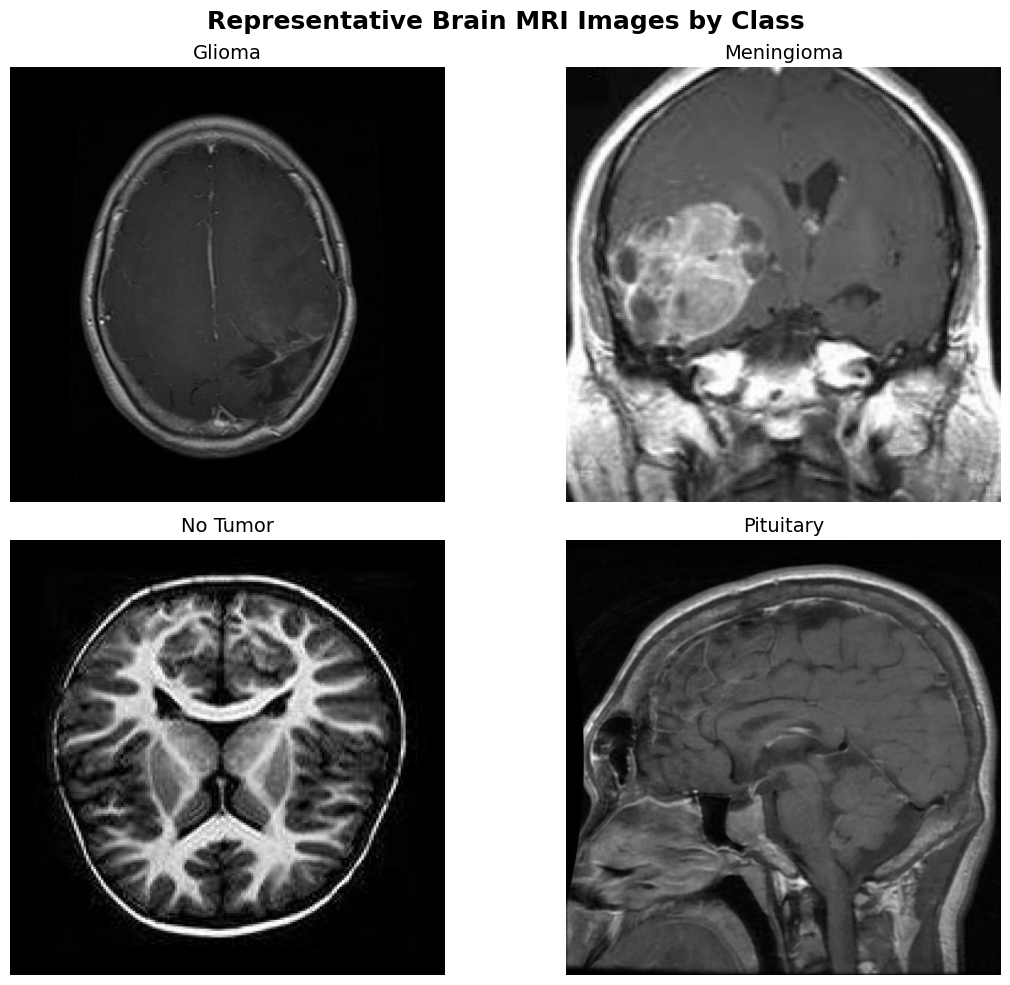

In [22]:
# ============================================================
# SAMPLE MRI IMAGES BY CLASS
# ============================================================

classes = ["glioma", "meningioma", "no_tumor", "pituitary"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, class_name in zip(axes.ravel(), classes):

    # Select images from the training set
    class_images = image_df[
        (image_df["Split"] == "train") &
        (image_df["Class"] == class_name)
    ]

    # Select one random image
    sample_image = class_images.sample(
        n=1,
        random_state=SEED
    ).iloc[0]

    # Load image
    img = Image.open(sample_image["File_Path"])

    # Display
    ax.imshow(img)
    ax.set_title(class_name.replace("_", " ").title(), fontsize=14)
    ax.axis("off")

plt.suptitle(
    "Representative Brain MRI Images by Class",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Multiple Samples per Class

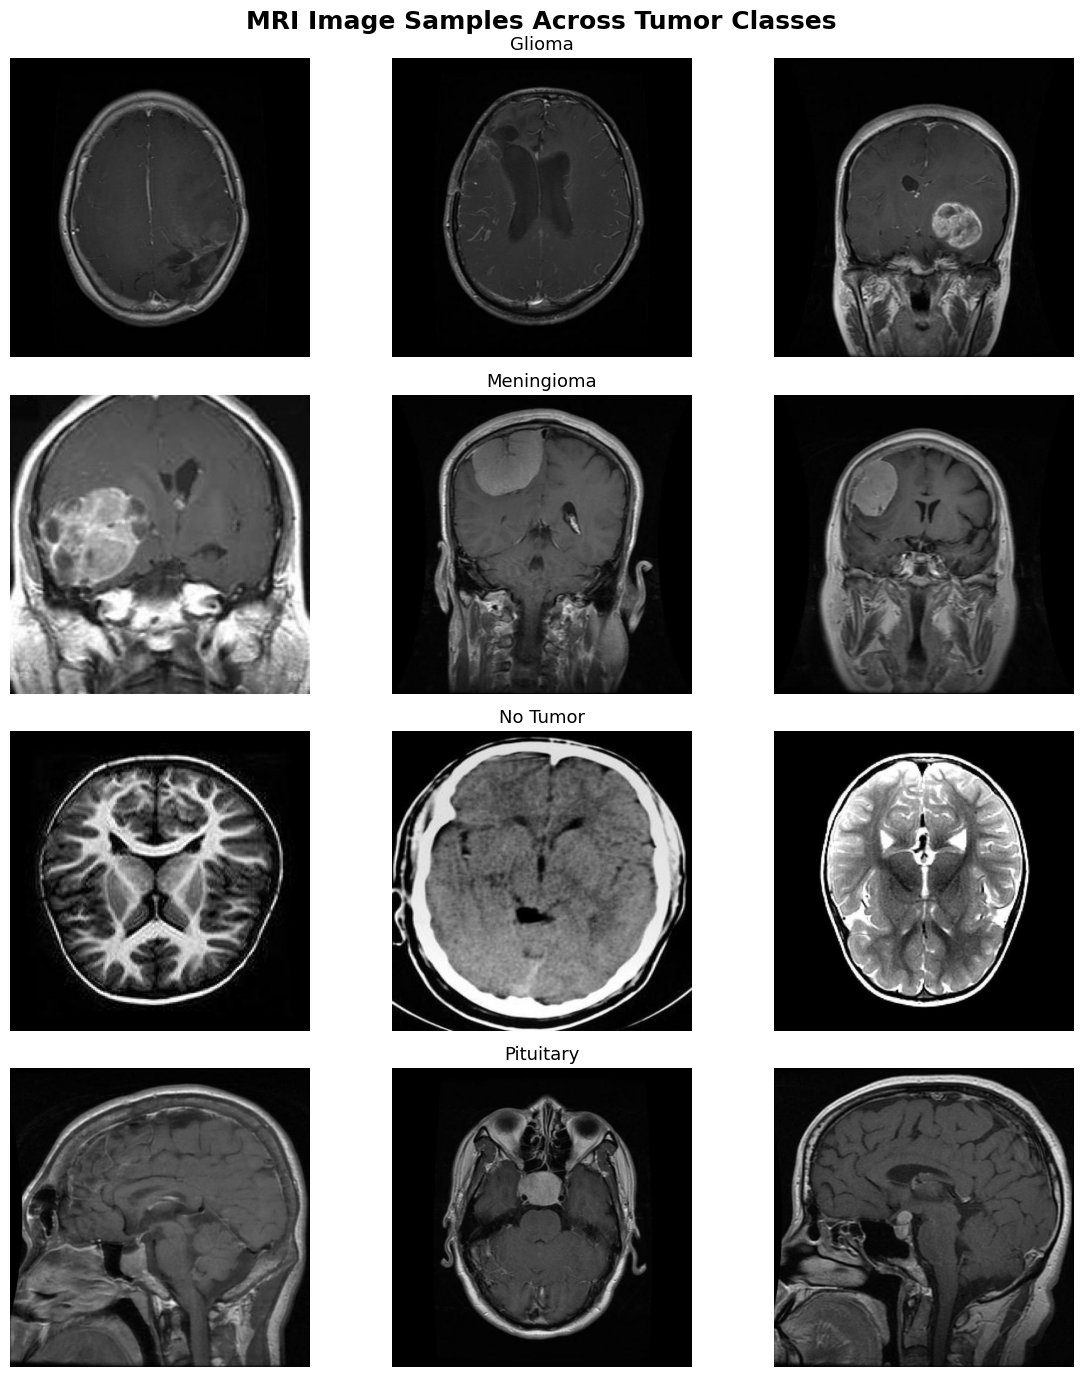

In [23]:
# ============================================================
# MULTIPLE MRI SAMPLES PER CLASS
# ============================================================

fig, axes = plt.subplots(
    4, 3,
    figsize=(12, 14)
)

for row, class_name in enumerate(classes):

    class_images = image_df[
        (image_df["Split"] == "train") &
        (image_df["Class"] == class_name)
    ]

    samples = class_images.sample(
        n=3,
        random_state=SEED
    )

    for col, (_, sample) in enumerate(samples.iterrows()):

        img = Image.open(sample["File_Path"])

        axes[row, col].imshow(img)
        axes[row, col].axis("off")

        if col == 1:
            axes[row, col].set_title(
                class_name.replace("_", " ").title(),
                fontsize=13
            )

plt.suptitle(
    "MRI Image Samples Across Tumor Classes",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Image Visualization Findings

Representative MRI images from all four target classes were visualized to understand the visual characteristics of the dataset.

The images show variation in the appearance and spatial patterns of brain MRI scans across the different classes. Multiple samples were displayed for each class to observe within-class variation.

The images are RGB JPEG images with a consistent sampled resolution of 640 × 640 pixels. Further preprocessing will standardize the input size to 224 × 224 pixels and normalize pixel values before model training.

## Class Distribution

In [24]:
# ============================================================
# CLASS DISTRIBUTION
# ============================================================

class_counts = (
    image_df["Class"]
    .value_counts()
    .reindex(classes)
)

print("Overall Class Distribution")
print("=" * 50)

display(
    class_counts
    .rename("Image_Count")
    .to_frame()
)

Overall Class Distribution


,Image_Count
Class,
glioma,809
meningioma,545
no_tumor,483
pituitary,613


In [25]:
# ============================================================
# CLASS DISTRIBUTION PERCENTAGE
# ============================================================

class_percentage = (
    image_df["Class"]
    .value_counts(normalize=True)
    .reindex(classes)
    .mul(100)
    .round(2)
)

class_distribution = pd.DataFrame({
    "Image_Count": class_counts,
    "Percentage": class_percentage
})

display(class_distribution)

,Image_Count,Percentage
Class,,
glioma,809,33.02
meningioma,545,22.24
no_tumor,483,19.71
pituitary,613,25.02


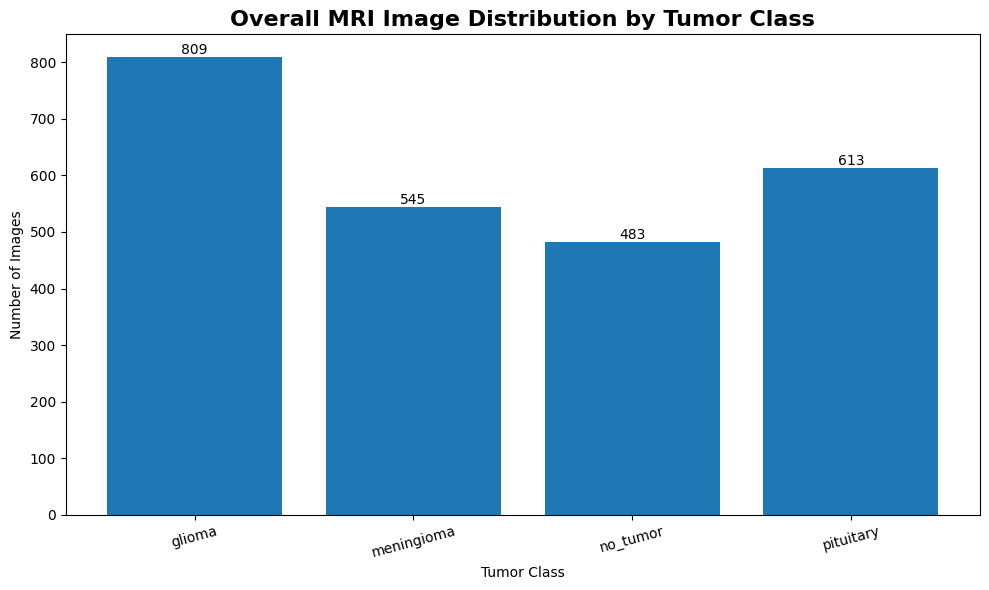

In [26]:
# ============================================================
# CLASS DISTRIBUTION VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 6))

bars = plt.bar(
    class_distribution.index,
    class_distribution["Image_Count"]
)

plt.title("Overall MRI Image Distribution by Tumor Class",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=15)

# Display values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Class Distribution Findings

The dataset contains 2,450 MRI images across four classes: glioma, meningioma, no_tumor, and pituitary.

Glioma is the largest class with 809 images (33.0%), followed by pituitary with 613 images (25.0%), meningioma with 545 images (22.2%), and no_tumor with 483 images (19.7%).

The class distribution is therefore not perfectly balanced. However, all four classes have substantial representation in the dataset. Class distribution will be considered during model training and evaluation to ensure that model performance is assessed across all four categories.

## Class Distribution Across Dataset Splits

Split,test,train,valid
Class,,,
glioma,80,568,161
meningioma,63,358,124
no_tumor,49,335,99
pituitary,54,438,121


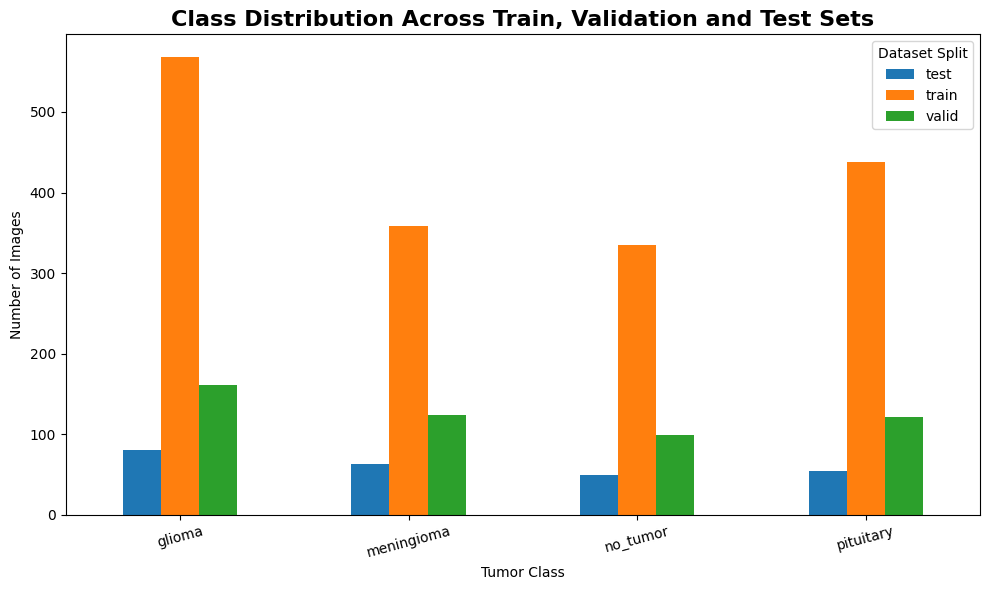

In [27]:
# ============================================================
# CLASS DISTRIBUTION ACROSS DATASET SPLITS
# ============================================================

split_class_counts = pd.crosstab(
    image_df["Class"],
    image_df["Split"]
)

display(split_class_counts)

# ============================================================
# VISUALIZE CLASS DISTRIBUTION ACROSS SPLITS
# ============================================================

ax = split_class_counts.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Class Distribution Across Train, Validation and Test Sets",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)
plt.legend(title="Dataset Split")

plt.tight_layout()
plt.show()

### Class Distribution Across Dataset Splits

The dataset is divided into three subsets: training, validation, and testing.

Each subset contains all four tumor classes: glioma, meningioma, no_tumor, and pituitary.

The training set contains the largest number of images for each class, while the validation and test sets contain smaller but consistently represented samples from every class.

The class proportions across the three subsets are broadly consistent, indicating that all four target categories are represented in each dataset split.

The training data will be used for model learning, the validation data for monitoring model performance during training, and the test data for final model evaluation.

## 5. ***Data Wrangling***

### Data Wrangling Code

In [19]:


# Create a working copy of the dataset
wrangled_df = image_df.copy()

# Standardize class names
wrangled_df["Class"] = wrangled_df["Class"].str.strip().str.lower()

# Standardize split names
wrangled_df["Split"] = wrangled_df["Split"].str.strip().str.lower()

# Check the cleaned values
print("Classes:", sorted(wrangled_df["Class"].unique()))
print("Splits :", sorted(wrangled_df["Split"].unique()))

print("\nDataset Shape:", wrangled_df.shape)

Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Splits : ['test', 'train', 'valid']

Dataset Shape: (2450, 4)


In [20]:
# ============================================================
# VALIDATE CLEANED DATASET
# ============================================================

print("Missing Values:")
display(wrangled_df.isnull().sum())

print("\nDuplicate Rows:")
print(wrangled_df.duplicated().sum())

print("\nDataset Shape:")
print(wrangled_df.shape)

Missing Values:


,0
Split,0
Class,0
Filename,0
File_Path,0



Duplicate Rows:
0

Dataset Shape:
(2450, 4)


### Data Wrangling Summary

The dataset was prepared by creating a working copy of the original dataset so that the original data remains unchanged.

The `Class` and `Split` columns were standardized by removing leading and trailing spaces and converting the values to lowercase.

The final dataset contains 2,450 records across four tumor classes and three predefined dataset splits.

Validation confirmed that there are no missing values and no duplicate rows. The cleaned dataset is therefore ready for the next stage of feature engineering and data preprocessing.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [21]:
# ============================================================
# HANDLING MISSING VALUES
# ============================================================

missing_values = wrangled_df.isnull().sum()

print("Missing values in each column:")
display(missing_values.to_frame(name="Missing_Count"))

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:


,Missing_Count
Split,0
Class,0
Filename,0
File_Path,0



Total missing values: 0


#### What all missing value imputation techniques have you used and why did you use those techniques?



No missing-value imputation technique was used because the dataset contains no missing values after data validation.

Therefore, techniques such as mean, median, mode, forward fill, or backward fill were not applicable to this dataset.

## 2. Image Resizing

In [22]:
# ============================================================
# IMAGE PREPROCESSING PARAMETERS
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4

print("Target Image Size:", IMG_SIZE)
print("Batch Size:", BATCH_SIZE)
print("Number of Classes:", NUM_CLASSES)

Target Image Size: (224, 224)
Batch Size: 32
Number of Classes: 4


## 3. Create Train, Validation and Test DataFrames

In [23]:
# ============================================================
# CREATE DATA SPLITS
# ============================================================

train_df = wrangled_df[wrangled_df["Split"] == "train"].copy()
valid_df = wrangled_df[wrangled_df["Split"] == "valid"].copy()
test_df = wrangled_df[wrangled_df["Split"] == "test"].copy()

print("Training images   :", len(train_df))
print("Validation images :", len(valid_df))
print("Testing images    :", len(test_df))

Training images   : 1699
Validation images : 505
Testing images    : 246


## 4. Resizing And Normalization

In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ============================================================
# RESIZING AND NORMALIZATION
# ============================================================

train_datagen = ImageDataGenerator(
    rescale=1./255
)

valid_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

# ============================================================
# CREATE IMAGE GENERATORS
# ============================================================

classes = ["glioma", "meningioma", "no_tumor", "pituitary"]

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="File_Path",
    y_col="Class",
    target_size=IMG_SIZE,
    classes=classes,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

valid_generator = valid_datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col="File_Path",
    y_col="Class",
    target_size=IMG_SIZE,
    classes=classes,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="File_Path",
    y_col="Class",
    target_size=IMG_SIZE,
    classes=classes,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 1699 validated image filenames belonging to 4 classes.
Found 505 validated image filenames belonging to 4 classes.
Found 246 validated image filenames belonging to 4 classes.


## 5. Verify the Preprocessing

In [25]:
# ============================================================
# VERIFY PREPROCESSING
# ============================================================

images, labels = next(train_generator)

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)
print("Minimum pixel value:", images.min())
print("Maximum pixel value:", images.max())

Batch image shape: (32, 224, 224, 3)
Batch label shape: (32, 4)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


### Pre-processing Verification

The preprocessing pipeline successfully resized the MRI images to `224 × 224` pixels and normalized their pixel values to the range `0–1`.

The generated batches have the expected shape of `(32, 224, 224, 3)`, confirming that the images are being processed as RGB images. The label shape `(32, 4)` confirms that the four tumor classes are encoded using categorical labels.

The preprocessing pipeline is therefore ready for the next stage of data augmentation and model development.

## **7. Data Augmentation**

## Create the augmentation pipeline

In [26]:
# ============================================================
# DATA AUGMENTATION
# ============================================================

train_augmented_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.15,
    brightness_range=(0.8, 1.2),
    width_shift_range=0.10,
    height_shift_range=0.10
)

print("Training data augmentation pipeline created successfully.")

Training data augmentation pipeline created successfully.


## Create the augmented training generator

In [27]:
# ============================================================
# AUGMENTED TRAINING GENERATOR
# ============================================================

train_augmented_generator = train_augmented_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="File_Path",
    y_col="Class",
    target_size=IMG_SIZE,
    classes=classes,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

print("Augmented training generator created successfully.")

Found 1699 validated image filenames belonging to 4 classes.
Augmented training generator created successfully.


## Verify augmented images

In [28]:
# ============================================================
# VERIFY AUGMENTED IMAGES
# ============================================================

aug_images, aug_labels = next(train_augmented_generator)

print("Augmented batch shape:", aug_images.shape)
print("Minimum pixel value:", aug_images.min())
print("Maximum pixel value:", aug_images.max())

Augmented batch shape: (32, 224, 224, 3)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


## Visualize Augmented Images

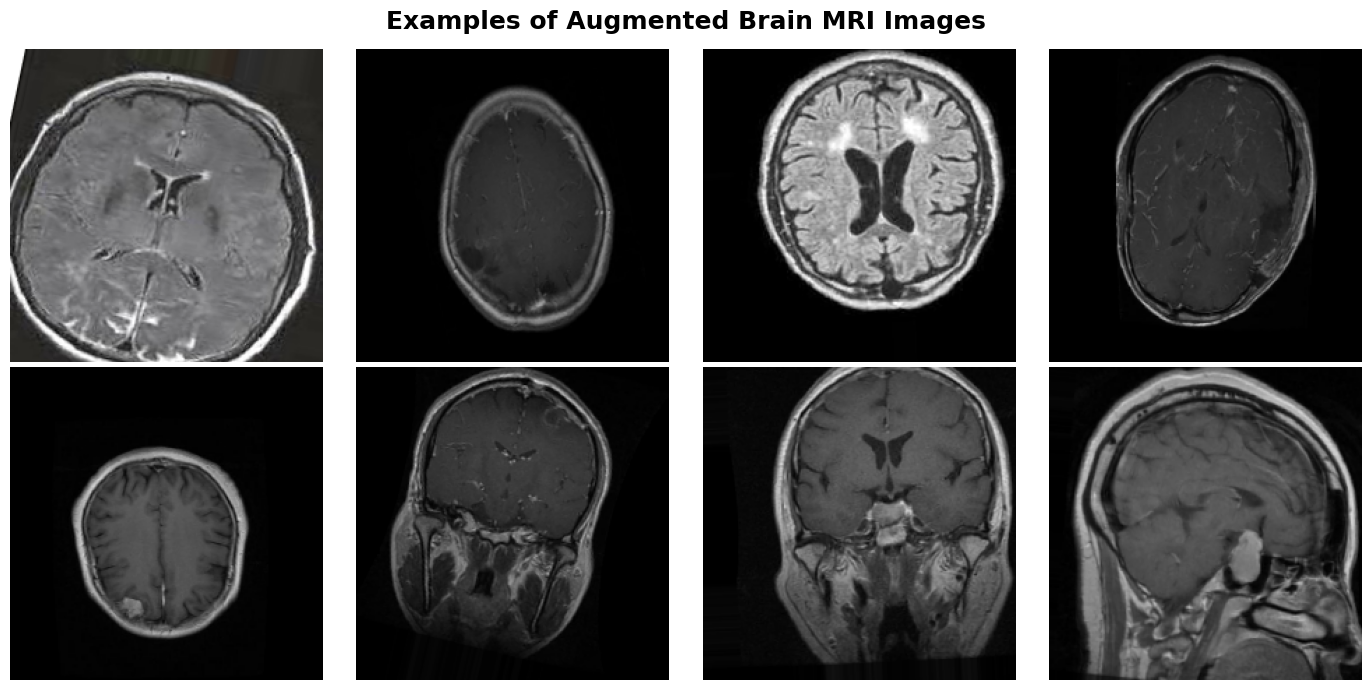

In [29]:
# ============================================================
# VISUALIZE AUGMENTED MRI IMAGES
# ============================================================

# Get one batch of augmented images
aug_images, aug_labels = next(train_augmented_generator)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(aug_images[i])
    ax.axis("off")

plt.suptitle(
    "Examples of Augmented Brain MRI Images",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Data Augmentation Findings

The augmented images demonstrate different variations generated from the original MRI images through rotation, flipping, zooming, brightness adjustment, and spatial shifting.

These transformations increase the diversity of the training data while preserving the overall image classification task.

Only the training dataset is augmented, while validation and test datasets remain unaugmented apart from resizing and pixel normalization.

## ***8. ML Model Implementation***

## ML Model - 1

### **Custom CNN**

In [ ]:
custom_cnn = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

custom_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,237,700 (50.50 MB)

 Trainable params: 13,236,228 (50.49 MB)

 Non-trainable params: 1,472 (5.75 KB)

## Compile the Custom CNN

In [ ]:
custom_cnn.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fresh Custom CNN compiled successfully.")

Fresh Custom CNN compiled successfully.


## EarlyStopping & ModelCheckpoint

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping_cnn = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint_cnn = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Brain_Tumor_MRI_Project/custom_cnn_clean_best.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

print("Fresh callbacks created successfully.")

Fresh callbacks created successfully.


## Train the Custom CNN

In [ ]:
EPOCHS = 30

custom_cnn_history = custom_cnn.fit(
    train_augmented_generator,
    validation_data=valid_generator,
    epochs=EPOCHS,
    callbacks=[
        early_stopping_cnn,
        model_checkpoint_cnn
    ]
)

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5758 - loss: 1.5563
Epoch 1: val_loss improved from None to 2.15622, saving model to /content/drive/MyDrive/Brain_Tumor_MRI_Project/custom_cnn_clean_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Brain_Tumor_MRI_Project/custom_cnn_clean_best.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 526s 9s/step - accuracy: 0.6286 - loss: 1.2067 - val_accuracy: 0.2554 - val_loss: 2.1562
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.6982 - loss: 0.8972
Epoch 2: val_loss did not improve from 2.15622
54/54 ━━━━━━━━━━━━━━━━━━━━ 443s 8s/step - accuracy: 0.6869 - loss: 0.9247 - val_accuracy: 0.2396 - val_loss: 4.4281
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.7074 - loss: 0.8180
Epoch 3: val_loss improved from 2.15622 to 1.82416, saving model to /content/drive/MyDrive/Brain_Tumor_MRI_Project/custom_cnn_clean_best.keras

Epoch 3: finished saving model to /content/drive/MyDrive/Brain_Tumor_MRI_Proje

## Custom CNN Training Summary

In [ ]:
best_epoch = np.argmin(custom_cnn_history.history["val_loss"]) + 1
best_val_loss = min(custom_cnn_history.history["val_loss"])
best_val_accuracy = max(custom_cnn_history.history["val_accuracy"])

print("Best Epoch:", best_epoch)
print("Best Validation Loss:", best_val_loss)
print("Best Validation Accuracy:", best_val_accuracy)
print("Epochs Actually Completed:", len(custom_cnn_history.history["loss"]))

Best Epoch: 13
Best Validation Loss: 0.5896866917610168
Best Validation Accuracy: 0.7861385941505432
Epochs Actually Completed: 18


### Custom CNN Training Summary

A custom Convolutional Neural Network (CNN) was developed from scratch for four-class brain MRI image classification: **Glioma, Meningioma, No Tumor, and Pituitary**.

The model accepts preprocessed MRI images of size **224 × 224 × 3**. It consists of four convolutional blocks with **32, 64, 128, and 256 filters**, respectively. Each block uses convolution, Batch Normalization, and Max Pooling to progressively extract and learn image features.

A fully connected layer with **256 neurons** and a **Dropout rate of 0.5** was used before the final classification layer. The output layer contains **4 neurons with Softmax activation**, corresponding to the four tumor classes.

The model contains **13,237,700 total parameters**, of which **13,236,228 are trainable** and **1,472 are non-trainable**.

The model was trained using the Adam optimizer and categorical cross-entropy loss. EarlyStopping and ModelCheckpoint were used to monitor validation loss and preserve the best model weights.

The training was configured for a maximum of 30 epochs. EarlyStopping terminated training after **18 epochs**, with the best validation loss of **0.58969** achieved at **Epoch 13**. The highest validation accuracy recorded during training was **78.61%**.

## Custom CNN Training and Validation Curves

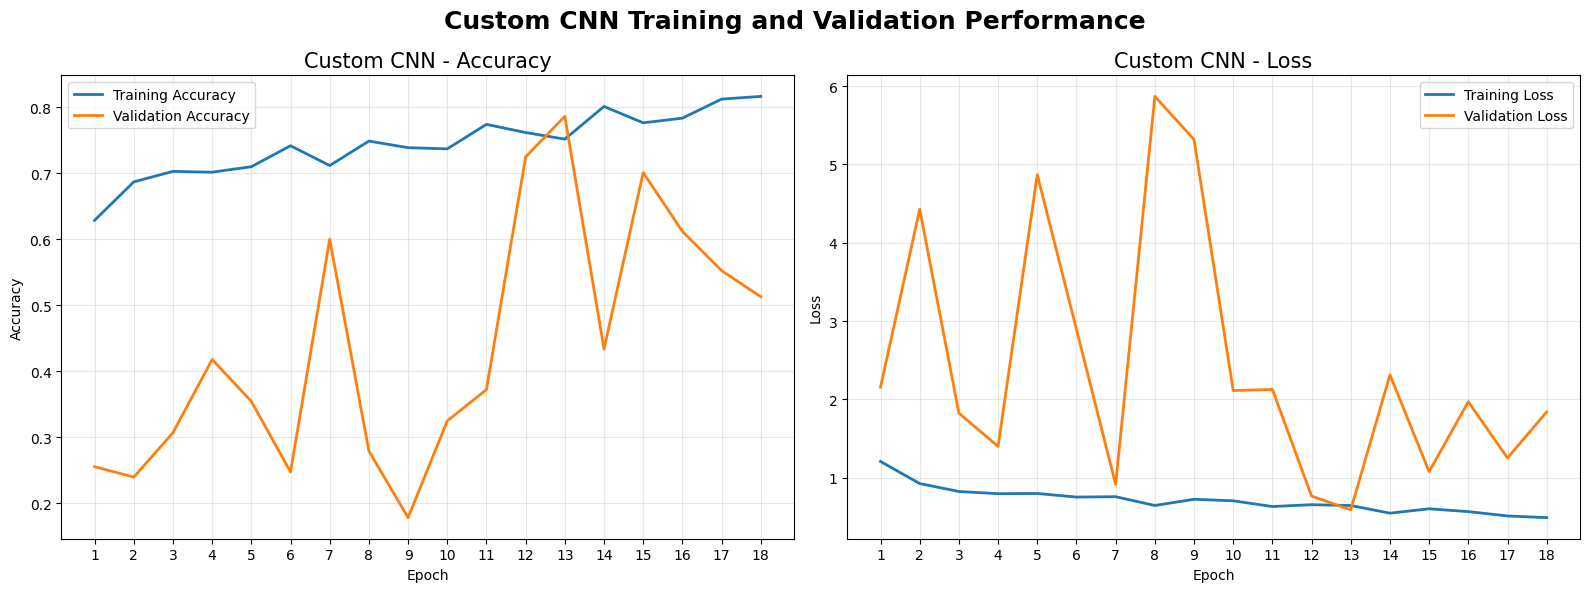

In [ ]:
# ============================================================
# CUSTOM CNN - TRAINING & VALIDATION CURVES
# ============================================================

history = custom_cnn_history.history

epochs_range = range(1, len(history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy
axes[0].plot(
    epochs_range,
    history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)

axes[0].plot(
    epochs_range,
    history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

axes[0].set_title("Custom CNN - Accuracy", fontsize=15)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks(epochs_range)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(
    epochs_range,
    history["loss"],
    label="Training Loss",
    linewidth=2
)

axes[1].plot(
    epochs_range,
    history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

axes[1].set_title("Custom CNN - Loss", fontsize=15)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_xticks(epochs_range)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(
    "Custom CNN Training and Validation Performance",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Custom CNN Training and Validation Performance

The following plots illustrate the training and validation performance of the Custom CNN across the completed training epochs.

The **accuracy plot** shows the change in training and validation accuracy, while the **loss plot** shows the corresponding training and validation loss.

Training accuracy generally increased throughout the training process, while validation accuracy showed greater variation. The validation loss reached its lowest value at Epoch 13, after which it did not show consistent improvement. Consequently, EarlyStopping terminated training at Epoch 18 and restored the weights from the best-performing epoch.

These training-history plots provide a visual representation of the model's learning behavior and validation performance.

## Create the Custom CNN .h5

In [39]:
from tensorflow.keras.models import load_model

custom_cnn_path = (
    "/content/drive/MyDrive/"
    "Brain_Tumor_MRI_Project/custom_cnn_clean_best.keras"
)

custom_cnn = load_model(custom_cnn_path)

print("Custom CNN loaded successfully.")

Custom CNN loaded successfully.


In [40]:
custom_cnn_h5_path = (
    "/content/drive/MyDrive/"
    "Brain_Tumor_MRI_Project/custom_cnn_best.h5"
)

custom_cnn.save(custom_cnn_h5_path)

print("Custom CNN .h5 model saved successfully:")
print(custom_cnn_h5_path)

Custom CNN .h5 model saved successfully:
/content/drive/MyDrive/Brain_Tumor_MRI_Project/custom_cnn_best.h5


## Custom CNN Test Set Evaluation

In [ ]:
# ============================================================
# CUSTOM CNN - TEST SET PREDICTIONS
# ============================================================

# Make sure the test generator starts from the first image
test_generator.reset()

# Generate prediction probabilities
test_predictions = custom_cnn.predict(
    test_generator,
    verbose=1
)

# Convert probabilities to predicted class indices
y_pred = np.argmax(test_predictions, axis=1)

# Get true class labels
y_true = test_generator.classes

print("Number of test images:", len(y_true))
print("Number of predictions:", len(y_pred))

8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step
Number of test images: 246
Number of predictions: 246


In [ ]:
# ============================================================
# CUSTOM CNN - EVALUATION METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Calculate evaluation metrics
test_accuracy = accuracy_score(y_true, y_pred)

test_precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Custom CNN Test Set Performance")
print("=" * 40)
print(f"Accuracy  : {test_accuracy:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1-Score  : {test_f1:.4f}")

Custom CNN Test Set Performance
Accuracy  : 0.8130
Precision : 0.8349
Recall    : 0.8130
F1-Score  : 0.8146


In [ ]:
# ============================================================
# CLASS-WISE CLASSIFICATION REPORT
# ============================================================

print("Classification Report")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=classes,
        digits=4,
        zero_division=0
    )
)

Classification Report
              precision    recall  f1-score   support

      glioma     1.0000    0.8250    0.9041        80
  meningioma     0.6984    0.6984    0.6984        63
    no_tumor     0.8780    0.7347    0.8000        49
   pituitary     0.7105    1.0000    0.8308        54

    accuracy                         0.8130       246
   macro avg     0.8217    0.8145    0.8083       246
weighted avg     0.8349    0.8130    0.8146       246



## Confusion Matrix

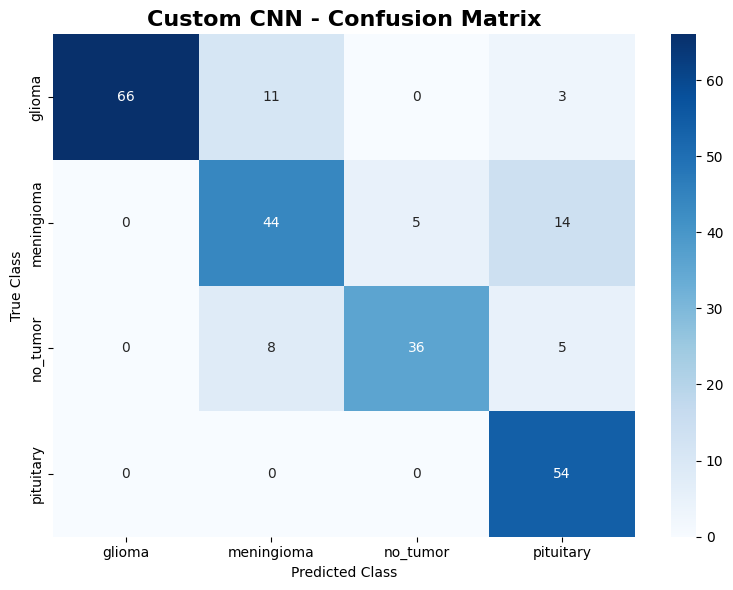

In [ ]:
# ============================================================
# CUSTOM CNN - CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title(
    "Custom CNN - Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.show()

### Custom CNN Evaluation Summary

The Custom CNN was evaluated on the independent test dataset containing 246 MRI images.

The model achieved an overall test accuracy of **81.30%**, with a weighted precision of **83.49%**, weighted recall of **81.30%**, and weighted F1-score of **81.46%**.

The confusion matrix shows that 66 of 80 glioma images, 44 of 63 meningioma images, 36 of 49 no-tumor images, and 54 of 54 pituitary images were correctly classified.

The model achieved perfect recall for the pituitary class in this test set, while the meningioma class showed more misclassification compared with the other classes. The confusion matrix provides a detailed view of these class-level prediction patterns.

Overall, the Custom CNN provides a baseline model for comparison with the pretrained transfer-learning models that will be implemented next.

## ML Model - 2
### **ResNet50 Transfer Learning**

## Load ResNet50

In [30]:
# ============================================================
# RESNET50 - LOAD PRETRAINED BASE MODEL
# ============================================================

from tensorflow.keras.applications import ResNet50

resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
resnet_base.trainable = False

print("ResNet50 loaded successfully.")
print("Total layers:", len(resnet_base.layers))
print("Trainable:", resnet_base.trainable)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
ResNet50 loaded successfully.
Total layers: 175
Trainable: False


## Build the ResNet50 classification model

In [31]:
# ============================================================
# RESNET50 - BUILD CLASSIFICATION MODEL
# ============================================================

resnet50_model = models.Sequential([

    resnet_base,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dense(256, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

resnet50_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,121,476 (92.02 MB)

 Trainable params: 529,668 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

## Compile ResNet50

In [32]:
# ============================================================
# COMPILE RESNET50
# ============================================================

resnet50_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("ResNet50 compiled successfully.")

ResNet50 compiled successfully.


## ResNet50 Callbacks

In [33]:
# ============================================================
# RESNET50 - CALLBACKS
# ============================================================

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

resnet50_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

resnet50_checkpoint_path = (
    "/content/drive/MyDrive/"
    "Brain_Tumor_MRI_Project/resnet50_best.keras"
)

resnet50_model_checkpoint = ModelCheckpoint(
    filepath=resnet50_checkpoint_path,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

print("ResNet50 callbacks created successfully.")
print("Checkpoint path:")
print(resnet50_checkpoint_path)

ResNet50 callbacks created successfully.
Checkpoint path:
/content/drive/MyDrive/Brain_Tumor_MRI_Project/resnet50_best.keras


## Train ResNet50

In [34]:
# ============================================================
# TRAIN RESNET50
# ============================================================

RESNET50_EPOCHS = 30

resnet50_history = resnet50_model.fit(
    train_augmented_generator,
    validation_data=valid_generator,
    epochs=RESNET50_EPOCHS,
    callbacks=[
        resnet50_early_stopping,
        resnet50_model_checkpoint
    ]
)

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.5215 - loss: 1.2315 
Epoch 1: val_loss improved from None to 1.37111, saving model to /content/drive/MyDrive/Brain_Tumor_MRI_Project/resnet50_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Brain_Tumor_MRI_Project/resnet50_best.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 1328s 24s/step - accuracy: 0.5639 - loss: 1.1309 - val_accuracy: 0.3307 - val_loss: 1.3711
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6127 - loss: 0.9643
Epoch 2: val_loss improved from 1.37111 to 1.21435, saving model to /content/drive/MyDrive/Brain_Tumor_MRI_Project/resnet50_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Brain_Tumor_MRI_Project/resnet50_best.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 426s 8s/step - accuracy: 0.6274 - loss: 0.9437 - val_accuracy: 0.2970 - val_loss: 1.2143
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6352 - loss: 0.9281
Epoch 3: val_loss improved from 1.21435 to 1

## ResNet50 training curves

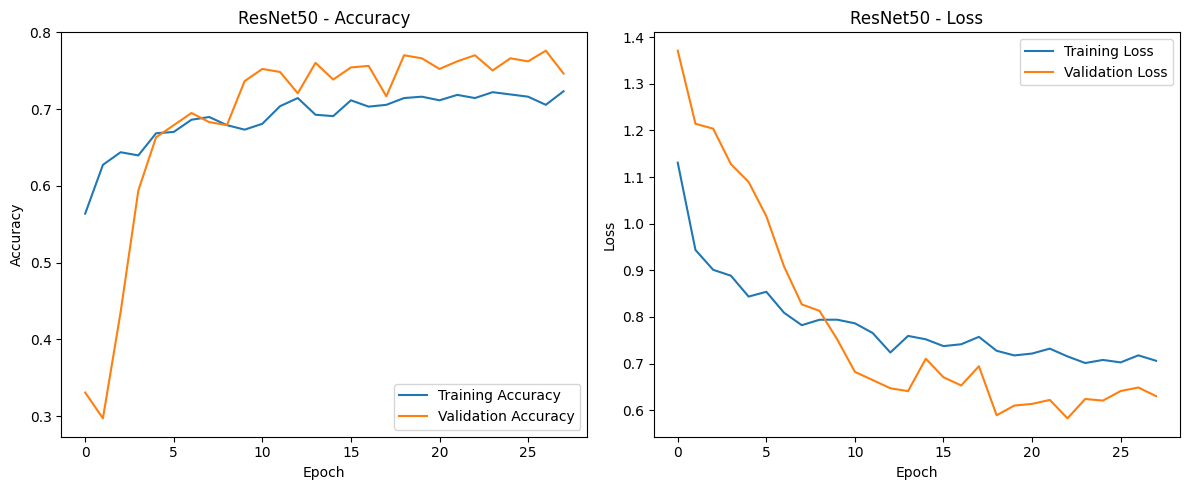

In [35]:
import matplotlib.pyplot as plt

history = resnet50_history.history

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history["accuracy"], label="Training Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")
plt.title("ResNet50 - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("ResNet50 - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## ResNet50 Training Performance

The ResNet50 transfer learning model was trained using ImageNet pretrained weights with the base layers frozen and a custom classification head for four tumor categories.

- The model was trained for a maximum of **30 epochs** with **EarlyStopping** based on validation loss.
- Training stopped at **Epoch 28**, and the weights from the best-performing **Epoch 23** were restored.
- The best validation loss was **0.58265**, with a validation accuracy of approximately **77.03%**.
- Training accuracy increased progressively and reached approximately **72%** by the final epoch.
- Validation accuracy improved substantially during training, reaching approximately **77%**.
- The validation loss generally decreased from about **1.37** to below **0.60**, although some fluctuations were observed in later epochs.
- The training and validation curves indicate that the ResNet50 model learned useful features from the MRI images while EarlyStopping helped prevent unnecessary additional training.
- The best model checkpoint was saved as `resnet50_best.keras`.

Overall, the training curves show **successful learning and convergence of the ResNet50 transfer learning model**, making it suitable for the next stage of **test-set evaluation**.

## save the final ResNet50 as .h5

In [36]:
resnet50_h5_path = (
    "/content/drive/MyDrive/"
    "Brain_Tumor_MRI_Project/resnet50_best.h5"
)

resnet50_model.save(resnet50_h5_path)

print("ResNet50 .h5 model saved successfully:")
print(resnet50_h5_path)

ResNet50 .h5 model saved successfully:
/content/drive/MyDrive/Brain_Tumor_MRI_Project/resnet50_best.h5


## ResNet50 Test Evaluation

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Reset test generator
test_generator.reset()

# Generate predictions
resnet50_predictions = resnet50_model.predict(
    test_generator,
    verbose=1
)

# Convert probabilities to class labels
y_pred_resnet50 = np.argmax(resnet50_predictions, axis=1)
y_true_resnet50 = test_generator.classes

print("Test images:", len(y_true_resnet50))
print("Predictions:", len(y_pred_resnet50))

8/8 ━━━━━━━━━━━━━━━━━━━━ 58s 7s/step
Test images: 246
Predictions: 246


## Calculate ResNet50 evaluation metrics

In [42]:
# ResNet50 evaluation metrics

resnet50_accuracy = accuracy_score(
    y_true_resnet50,
    y_pred_resnet50
)

resnet50_precision = precision_score(
    y_true_resnet50,
    y_pred_resnet50,
    average="weighted",
    zero_division=0
)

resnet50_recall = recall_score(
    y_true_resnet50,
    y_pred_resnet50,
    average="weighted",
    zero_division=0
)

resnet50_f1 = f1_score(
    y_true_resnet50,
    y_pred_resnet50,
    average="weighted",
    zero_division=0
)

print("ResNet50 Test Evaluation")
print("-" * 30)
print(f"Accuracy :  {resnet50_accuracy:.4f} ({resnet50_accuracy*100:.2f}%)")
print(f"Precision:  {resnet50_precision:.4f} ({resnet50_precision*100:.2f}%)")
print(f"Recall   :  {resnet50_recall:.4f} ({resnet50_recall*100:.2f}%)")
print(f"F1-Score :  {resnet50_f1:.4f} ({resnet50_f1*100:.2f}%)")

ResNet50 Test Evaluation
------------------------------
Accuracy :  0.7805 (78.05%)
Precision:  0.7781 (77.81%)
Recall   :  0.7805 (78.05%)
F1-Score :  0.7744 (77.44%)


In [43]:
from sklearn.metrics import classification_report

class_names = ["glioma", "meningioma", "no_tumor", "pituitary"]

resnet50_report = classification_report(
    y_true_resnet50,
    y_pred_resnet50,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("ResNet50 Classification Report")
print("-" * 40)
print(resnet50_report)

ResNet50 Classification Report
----------------------------------------
              precision    recall  f1-score   support

      glioma     0.7927    0.8125    0.8025        80
  meningioma     0.7347    0.5714    0.6429        63
    no_tumor     0.8125    0.7959    0.8041        49
   pituitary     0.7761    0.9630    0.8595        54

    accuracy                         0.7805       246
   macro avg     0.7790    0.7857    0.7772       246
weighted avg     0.7781    0.7805    0.7744       246



## ResNet50 Classification Summary
- Glioma: F1-score 80.25%
- Meningioma: F1-score 64.29%
- No Tumor: F1-score 80.41%
- Pituitary: F1-score 85.95%
- Overall accuracy: 78.05%
- Weighted F1-score: 77.44%
The main weaker class is meningioma, particularly its recall of 57.14%. Pituitary has the strongest recall at 96.30%.

## ResNet50 Confusion Matrix

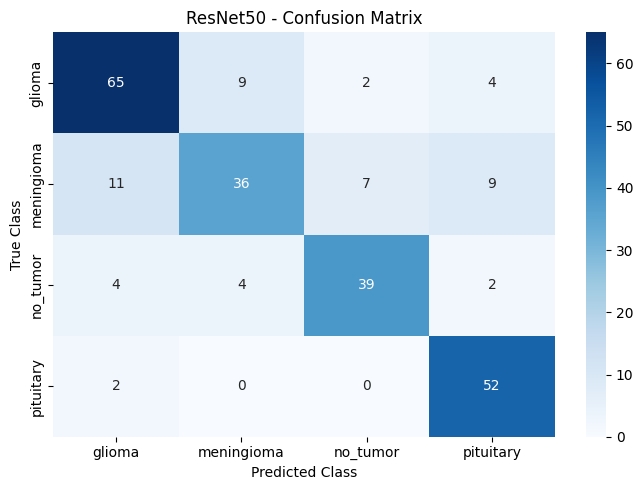

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

resnet50_cm = confusion_matrix(
    y_true_resnet50,
    y_pred_resnet50
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    resnet50_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("ResNet50 - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.show()

## ResNet50 Model Evaluation

The ResNet50 transfer learning model was evaluated on the independent test dataset containing 246 MRI images across four classes: glioma, meningioma, no_tumor, and pituitary.

- **Test Accuracy:** 78.05%
- **Weighted Precision:** 77.81%
- **Weighted Recall:** 78.05%
- **Weighted F1-Score:** 77.44%

### Class-wise Performance

- **Glioma:** Precision 79.27%, Recall 81.25%, F1-Score 80.25%
- **Meningioma:** Precision 73.47%, Recall 57.14%, F1-Score 64.29%
- **No Tumor:** Precision 81.25%, Recall 79.59%, F1-Score 80.41%
- **Pituitary:** Precision 77.61%, Recall 96.30%, F1-Score 85.95%

### Confusion Matrix Findings

The confusion matrix shows that 65 out of 80 glioma images, 36 out of 63 meningioma images, 39 out of 49 no_tumor images, and 52 out of 54 pituitary images were correctly classified.

The model performed strongest on the pituitary class, while meningioma showed comparatively lower recall and F1-score. Some meningioma images were misclassified as glioma, no_tumor, and pituitary.

Overall, the ResNet50 model achieved **78.05% test accuracy** and provides a useful transfer learning model for comparison with the Custom CNN and other pretrained architectures.

## ML Model - 3
## MobileNetV2

## Load the pretrained MobileNetV2

In [45]:
from tensorflow.keras.applications import MobileNetV2

mobilenet_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
mobilenet_base.trainable = False

print("MobileNetV2 loaded successfully.")
print("Total layers:", len(mobilenet_base.layers))
print("Trainable:", mobilenet_base.trainable)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MobileNetV2 loaded successfully.
Total layers: 154
Trainable: False


## Build the MobileNetV2 Classification Head

In [46]:
mobilenetv2_model = models.Sequential([
    mobilenet_base,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

mobilenetv2_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,592,068 (9.89 MB)

 Trainable params: 331,524 (1.26 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

## Compile MobileNetV2

In [47]:
mobilenetv2_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("MobileNetV2 compiled successfully.")

MobileNetV2 compiled successfully.


## Callbacks for MobileNetV2

In [48]:
mobilenetv2_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

mobilenetv2_checkpoint_path = (
    "/content/drive/MyDrive/"
    "Brain_Tumor_MRI_Project/mobilenetv2_best.keras"
)

mobilenetv2_model_checkpoint = ModelCheckpoint(
    filepath=mobilenetv2_checkpoint_path,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

print("MobileNetV2 callbacks created successfully.")

MobileNetV2 callbacks created successfully.


## Train MobileNetV2

In [49]:
MOBILENETV2_EPOCHS = 30

mobilenetv2_history = mobilenetv2_model.fit(
    train_augmented_generator,
    validation_data=valid_generator,
    epochs=MOBILENETV2_EPOCHS,
    callbacks=[
        mobilenetv2_early_stopping,
        mobilenetv2_model_checkpoint
    ]
)

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6391 - loss: 1.1220
Epoch 1: val_loss improved from None to 0.87909, saving model to /content/drive/MyDrive/Brain_Tumor_MRI_Project/mobilenetv2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Brain_Tumor_MRI_Project/mobilenetv2_best.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 148s 3s/step - accuracy: 0.7446 - loss: 0.7965 - val_accuracy: 0.7069 - val_loss: 0.8791
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8284 - loss: 0.5693
Epoch 2: val_loss improved from 0.87909 to 0.50889, saving model to /content/drive/MyDrive/Brain_Tumor_MRI_Project/mobilenetv2_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Brain_Tumor_MRI_Project/mobilenetv2_best.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.8393 - loss: 0.5254 - val_accuracy: 0.8139 - val_loss: 0.5089
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8544 - loss: 0.3862
Epoch 3: val_loss improved from 0.50

## MobileNetV2 training accuracy/loss curves

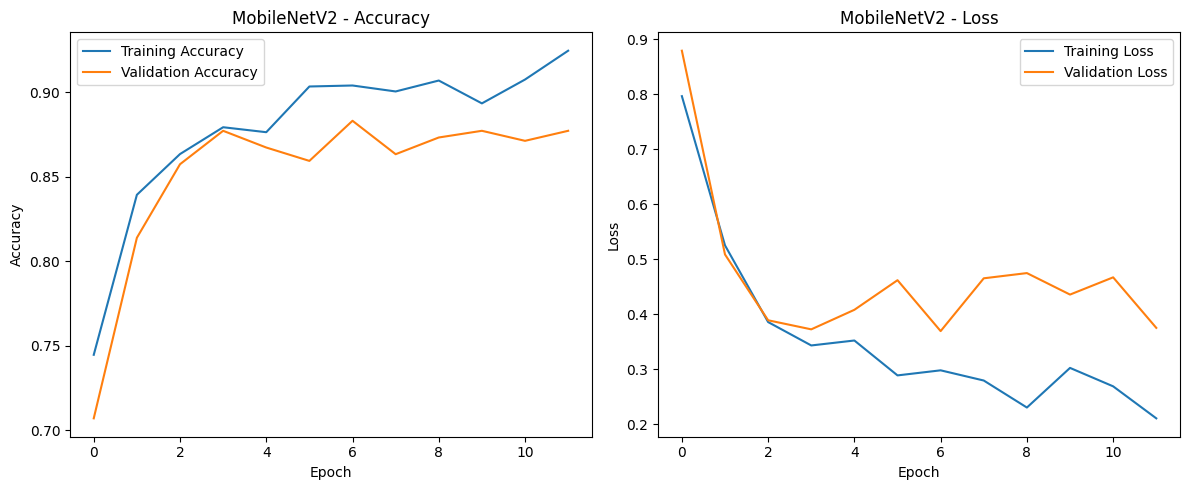

In [50]:
import matplotlib.pyplot as plt

history = mobilenetv2_history.history

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history["accuracy"], label="Training Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")
plt.title("MobileNetV2 - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("MobileNetV2 - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## MobileNetV2 Training Performance

The MobileNetV2 transfer learning model was trained using ImageNet pretrained weights with the base layers frozen and a custom classification head for four tumor categories.

- The model was trained for a maximum of **30 epochs** with **EarlyStopping** based on validation loss.
- Training stopped at **Epoch 12**, and the weights from the best-performing **Epoch 7** were restored.
- The best validation loss was **0.36963**, with a validation accuracy of **88.32%**.
- Training accuracy increased progressively and reached approximately **92.47%** by Epoch 12.
- Validation accuracy reached its highest value of **88.32% at Epoch 7**.
- Training loss continued to decrease, while validation loss showed fluctuations after the best epoch.
- The later divergence between training and validation performance indicates some overfitting, which was controlled using EarlyStopping.
- The best model checkpoint was saved as `mobilenetv2_best.keras`.

Overall, the training curves show that the MobileNetV2 model learned effectively from the MRI dataset and achieved strong validation performance. The restored best model is ready for independent test-set evaluation.

## MobileNetV2 Test Evaluation

In [51]:
# MobileNetV2 test-set predictions

test_generator.reset()

mobilenetv2_predictions = mobilenetv2_model.predict(
    test_generator,
    verbose=1
)

y_pred_mobilenetv2 = np.argmax(
    mobilenetv2_predictions,
    axis=1
)

y_true_mobilenetv2 = test_generator.classes

print("Test images:", len(y_true_mobilenetv2))
print("Predictions:", len(y_pred_mobilenetv2))

8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step
Test images: 246
Predictions: 246


## Calculate MobileNetV2 metrics

In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

mobilenetv2_accuracy = accuracy_score(
    y_true_mobilenetv2,
    y_pred_mobilenetv2
)

mobilenetv2_precision = precision_score(
    y_true_mobilenetv2,
    y_pred_mobilenetv2,
    average="weighted",
    zero_division=0
)

mobilenetv2_recall = recall_score(
    y_true_mobilenetv2,
    y_pred_mobilenetv2,
    average="weighted",
    zero_division=0
)

mobilenetv2_f1 = f1_score(
    y_true_mobilenetv2,
    y_pred_mobilenetv2,
    average="weighted",
    zero_division=0
)

print("MobileNetV2 Test Evaluation")
print("-" * 32)
print(f"Accuracy :  {mobilenetv2_accuracy:.4f} ({mobilenetv2_accuracy*100:.2f}%)")
print(f"Precision:  {mobilenetv2_precision:.4f} ({mobilenetv2_precision*100:.2f}%)")
print(f"Recall   :  {mobilenetv2_recall:.4f} ({mobilenetv2_recall*100:.2f}%)")
print(f"F1-Score :  {mobilenetv2_f1:.4f} ({mobilenetv2_f1*100:.2f}%)")

MobileNetV2 Test Evaluation
--------------------------------
Accuracy :  0.8415 (84.15%)
Precision:  0.8472 (84.72%)
Recall   :  0.8415 (84.15%)
F1-Score :  0.8361 (83.61%)


## Class-wise Classification Report

In [53]:
from sklearn.metrics import classification_report

class_names = ["glioma", "meningioma", "no_tumor", "pituitary"]

mobilenetv2_report = classification_report(
    y_true_mobilenetv2,
    y_pred_mobilenetv2,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("MobileNetV2 Classification Report")
print("-" * 42)
print(mobilenetv2_report)

MobileNetV2 Classification Report
------------------------------------------
              precision    recall  f1-score   support

      glioma     0.8523    0.9375    0.8929        80
  meningioma     0.8163    0.6349    0.7143        63
    no_tumor     0.9500    0.7755    0.8539        49
   pituitary     0.7826    1.0000    0.8780        54

    accuracy                         0.8415       246
   macro avg     0.8503    0.8370    0.8348       246
weighted avg     0.8472    0.8415    0.8361       246



## MobileNetV2 Confusion Matrix

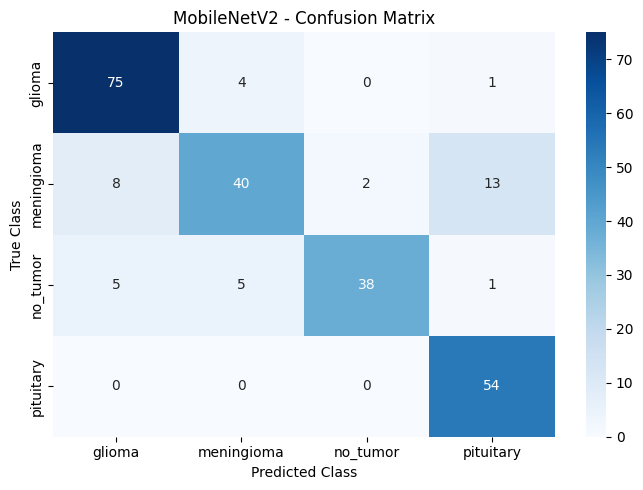

In [54]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

mobilenetv2_cm = confusion_matrix(
    y_true_mobilenetv2,
    y_pred_mobilenetv2
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    mobilenetv2_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("MobileNetV2 - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.show()

## MobileNetV2 Model Evaluation

The MobileNetV2 transfer learning model was evaluated on the independent test dataset containing 246 MRI images across four classes: glioma, meningioma, no_tumor, and pituitary.

- **Test Accuracy:** 84.15%
- **Weighted Precision:** 84.72%
- **Weighted Recall:** 84.15%
- **Weighted F1-Score:** 83.61%

### Class-wise Performance

- **Glioma:** Precision 85.23%, Recall 93.75%, F1-Score 89.29%
- **Meningioma:** Precision 81.63%, Recall 63.49%, F1-Score 71.43%
- **No Tumor:** Precision 95.00%, Recall 77.55%, F1-Score 85.39%
- **Pituitary:** Precision 78.26%, Recall 100.00%, F1-Score 87.80%

### Confusion Matrix Findings

The confusion matrix shows that 75 out of 80 glioma images, 40 out of 63 meningioma images, 38 out of 49 no_tumor images, and 54 out of 54 pituitary images were correctly classified.

The model performed strongly on the glioma and pituitary classes. Pituitary achieved 100% recall on the test dataset, while glioma achieved 93.75% recall. Meningioma showed comparatively lower recall at 63.49%, with several images being classified as pituitary or glioma.

Overall, the MobileNetV2 model achieved **84.15% test accuracy** and a **83.61% weighted F1-score**, making it the strongest-performing model among the Custom CNN, ResNet50, and MobileNetV2 models evaluated so far.

## MobileNetV2  .h5

In [55]:
mobilenetv2_h5_path = (
    "/content/drive/MyDrive/"
    "Brain_Tumor_MRI_Project/mobilenetv2_best.h5"
)

mobilenetv2_model.save(mobilenetv2_h5_path)

print("MobileNetV2 .h5 model saved successfully:")
print(mobilenetv2_h5_path)

MobileNetV2 .h5 model saved successfully:
/content/drive/MyDrive/Brain_Tumor_MRI_Project/mobilenetv2_best.h5


## ML Model 4 — InceptionV3

## Load pretrained InceptionV3

In [56]:
from tensorflow.keras.applications import InceptionV3

inception_base = InceptionV3(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
inception_base.trainable = False

print("InceptionV3 loaded successfully.")
print("Total layers:", len(inception_base.layers))
print("Trainable:", inception_base.trainable)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
InceptionV3 loaded successfully.
Total layers: 311
Trainable: False


## Build InceptionV3 Classification Head

In [57]:
inceptionv3_model = models.Sequential([
    inception_base,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

inceptionv3_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_96          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,336,548 (85.21 MB)

 Trainable params: 529,668 (2.02 MB)

 Non-trainable params: 21,806,880 (83.19 MB)

## Compile InceptionV3

In [58]:
inceptionv3_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("InceptionV3 compiled successfully.")

InceptionV3 compiled successfully.


## Create fresh InceptionV3 callbacks

In [59]:
inceptionv3_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

inceptionv3_checkpoint_path = (
    "/content/drive/MyDrive/"
    "Brain_Tumor_MRI_Project/inceptionv3_best.keras"
)

inceptionv3_model_checkpoint = ModelCheckpoint(
    filepath=inceptionv3_checkpoint_path,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

print("InceptionV3 callbacks created successfully.")

InceptionV3 callbacks created successfully.


## Train InceptionV3

In [60]:
INCEPTIONV3_EPOCHS = 30

inceptionv3_history = inceptionv3_model.fit(
    train_augmented_generator,
    validation_data=valid_generator,
    epochs=INCEPTIONV3_EPOCHS,
    callbacks=[
        inceptionv3_early_stopping,
        inceptionv3_model_checkpoint
    ]
)

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6195 - loss: 1.2922
Epoch 1: val_loss improved from None to 0.69722, saving model to /content/drive/MyDrive/Brain_Tumor_MRI_Project/inceptionv3_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Brain_Tumor_MRI_Project/inceptionv3_best.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 316s 6s/step - accuracy: 0.7104 - loss: 1.0061 - val_accuracy: 0.7624 - val_loss: 0.6972
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8186 - loss: 0.6323
Epoch 2: val_loss improved from 0.69722 to 0.44327, saving model to /content/drive/MyDrive/Brain_Tumor_MRI_Project/inceptionv3_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Brain_Tumor_MRI_Project/inceptionv3_best.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 301s 6s/step - accuracy: 0.8099 - loss: 0.6190 - val_accuracy: 0.8337 - val_loss: 0.4433
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8403 - loss: 0.5480
Epoch 3: val_loss did not improve fr

## InceptionV3 training curves

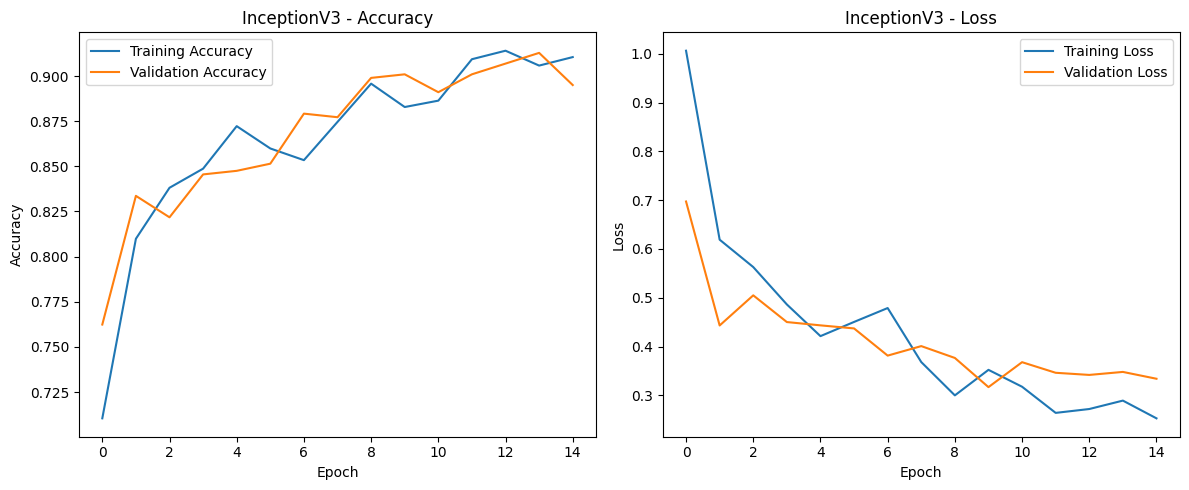

In [61]:
import matplotlib.pyplot as plt

history = inceptionv3_history.history

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history["accuracy"], label="Training Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")
plt.title("InceptionV3 - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("InceptionV3 - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## InceptionV3 Training Performance

The InceptionV3 transfer learning model was trained using ImageNet pretrained weights with the base layers frozen and a custom classification head for four tumor categories.

- The model was trained for a maximum of **30 epochs** with **EarlyStopping** based on validation loss.
- Training stopped at **Epoch 15**, and the weights from the best-performing **Epoch 10** were restored.
- The best validation loss was **0.31696**, with a validation accuracy of **90.10%**.
- The highest validation accuracy observed during training was approximately **91.29% at Epoch 14**.
- Training accuracy increased progressively and reached approximately **91%** during the later epochs.
- Training loss decreased substantially throughout training, while validation loss generally decreased with some fluctuations.
- The training and validation accuracy curves remained relatively close during the later epochs, indicating good learning behaviour.
- EarlyStopping prevented unnecessary additional training after the validation loss stopped improving.
- The best model checkpoint was saved as `inceptionv3_best.keras`.

Overall, the training curves demonstrate that the InceptionV3 model learned effectively from the MRI dataset and achieved strong validation performance. The restored best model is ready for independent test-set evaluation.

## InceptionV3 Test Evaluation

In [62]:
# InceptionV3 test-set predictions

test_generator.reset()

inceptionv3_predictions = inceptionv3_model.predict(
    test_generator,
    verbose=1
)

y_pred_inceptionv3 = np.argmax(
    inceptionv3_predictions,
    axis=1
)

y_true_inceptionv3 = test_generator.classes

print("Test images:", len(y_true_inceptionv3))
print("Predictions:", len(y_pred_inceptionv3))


8/8 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step
Test images: 246
Predictions: 246


## Calculate InceptionV3 metrics

In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

inceptionv3_accuracy = accuracy_score(
    y_true_inceptionv3,
    y_pred_inceptionv3
)

inceptionv3_precision = precision_score(
    y_true_inceptionv3,
    y_pred_inceptionv3,
    average="weighted",
    zero_division=0
)

inceptionv3_recall = recall_score(
    y_true_inceptionv3,
    y_pred_inceptionv3,
    average="weighted",
    zero_division=0
)

inceptionv3_f1 = f1_score(
    y_true_inceptionv3,
    y_pred_inceptionv3,
    average="weighted",
    zero_division=0
)

print("InceptionV3 Test Evaluation")
print("-" * 32)
print(f"Accuracy :  {inceptionv3_accuracy:.4f} ({inceptionv3_accuracy*100:.2f}%)")
print(f"Precision:  {inceptionv3_precision:.4f} ({inceptionv3_precision*100:.2f}%)")
print(f"Recall   :  {inceptionv3_recall:.4f} ({inceptionv3_recall*100:.2f}%)")
print(f"F1-Score :  {inceptionv3_f1:.4f} ({inceptionv3_f1*100:.2f}%)")

InceptionV3 Test Evaluation
--------------------------------
Accuracy :  0.8618 (86.18%)
Precision:  0.8639 (86.39%)
Recall   :  0.8618 (86.18%)
F1-Score :  0.8614 (86.14%)


## InceptionV3 Classification Report

In [64]:
from sklearn.metrics import classification_report

class_names = ["glioma", "meningioma", "no_tumor", "pituitary"]

inceptionv3_report = classification_report(
    y_true_inceptionv3,
    y_pred_inceptionv3,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("InceptionV3 Classification Report")
print("-" * 42)
print(inceptionv3_report)

InceptionV3 Classification Report
------------------------------------------
              precision    recall  f1-score   support

      glioma     0.9024    0.9250    0.9136        80
  meningioma     0.7966    0.7460    0.7705        63
    no_tumor     0.9545    0.8571    0.9032        49
   pituitary     0.8033    0.9074    0.8522        54

    accuracy                         0.8618       246
   macro avg     0.8642    0.8589    0.8599       246
weighted avg     0.8639    0.8618    0.8614       246



## InceptionV3 Confusion Matrix

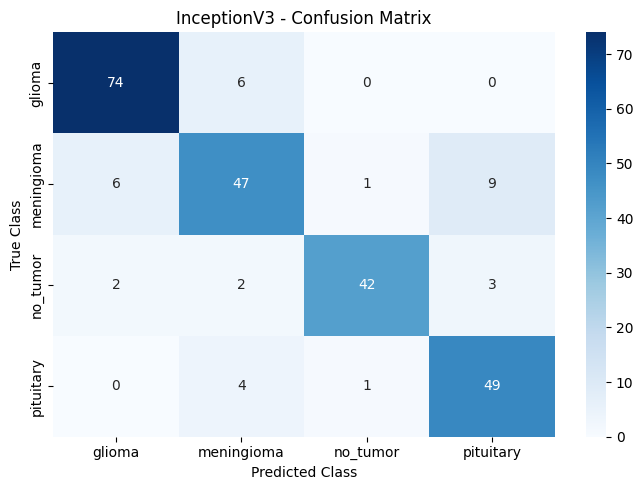

In [65]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

inceptionv3_cm = confusion_matrix(
    y_true_inceptionv3,
    y_pred_inceptionv3
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    inceptionv3_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("InceptionV3 - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.show()

## InceptionV3 Model Evaluation

The InceptionV3 transfer learning model was evaluated on the independent test dataset containing 246 MRI images across four classes: glioma, meningioma, no_tumor, and pituitary.

- **Test Accuracy:** 86.18%
- **Weighted Precision:** 86.39%
- **Weighted Recall:** 86.18%
- **Weighted F1-Score:** 86.14%

### Class-wise Performance

- **Glioma:** Precision 90.24%, Recall 92.50%, F1-Score 91.36%
- **Meningioma:** Precision 79.66%, Recall 74.60%, F1-Score 77.05%
- **No Tumor:** Precision 95.45%, Recall 85.71%, F1-Score 90.32%
- **Pituitary:** Precision 80.33%, Recall 90.74%, F1-Score 85.22%

### Confusion Matrix Findings

The confusion matrix shows that 74 out of 80 glioma images, 47 out of 63 meningioma images, 42 out of 49 no_tumor images, and 49 out of 54 pituitary images were correctly classified.

The model performed strongest on the glioma and no_tumor classes. Glioma achieved a recall of 92.50%, while no_tumor achieved a precision of 95.45%. Meningioma showed comparatively lower performance, with a recall of 74.60%, and some meningioma images were misclassified as pituitary or glioma.

Overall, the InceptionV3 model achieved **86.18% test accuracy** and an **86.14% weighted F1-score**, making it the strongest-performing model among the Custom CNN, ResNet50, MobileNetV2, and InceptionV3 models evaluated so far.

## InceptionV3 .h5

In [66]:
inceptionv3_h5_path = (
    "/content/drive/MyDrive/"
    "Brain_Tumor_MRI_Project/inceptionv3_best.h5"
)

inceptionv3_model.save(inceptionv3_h5_path)

print("InceptionV3 .h5 model saved successfully:")
print(inceptionv3_h5_path)

InceptionV3 .h5 model saved successfully:
/content/drive/MyDrive/Brain_Tumor_MRI_Project/inceptionv3_best.h5


## ML Model 5 — EfficientNetB0

## Load pretrained EfficientNetB0

In [67]:
from tensorflow.keras.applications import EfficientNetB0

efficientnet_base = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
efficientnet_base.trainable = False

print("EfficientNetB0 loaded successfully.")
print("Total layers:", len(efficientnet_base.layers))
print("Trainable:", efficientnet_base.trainable)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
EfficientNetB0 loaded successfully.
Total layers: 238
Trainable: False


## Build EfficientNetB0 Classification Head

In [68]:
efficientnetb0_model = models.Sequential([
    efficientnet_base,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

efficientnetb0_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_97          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,655 (16.72 MB)

 Trainable params: 331,524 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## Compile EfficientNetB0

In [69]:
efficientnetb0_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("EfficientNetB0 compiled successfully.")

EfficientNetB0 compiled successfully.


## Create fresh EfficientNetB0 callbacks

In [70]:
efficientnetb0_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

efficientnetb0_checkpoint_path = (
    "/content/drive/MyDrive/"
    "Brain_Tumor_MRI_Project/efficientnetb0_best.keras"
)

efficientnetb0_model_checkpoint = ModelCheckpoint(
    filepath=efficientnetb0_checkpoint_path,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

print("EfficientNetB0 callbacks created successfully.")

EfficientNetB0 callbacks created successfully.


## Train EfficientNetB0

In [71]:
EFFICIENTNETB0_EPOCHS = 30

efficientnetb0_history = efficientnetb0_model.fit(
    train_augmented_generator,
    validation_data=valid_generator,
    epochs=EFFICIENTNETB0_EPOCHS,
    callbacks=[
        efficientnetb0_early_stopping,
        efficientnetb0_model_checkpoint
    ]
)

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2618 - loss: 1.8158
Epoch 1: val_loss improved from None to 1.40074, saving model to /content/drive/MyDrive/Brain_Tumor_MRI_Project/efficientnetb0_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Brain_Tumor_MRI_Project/efficientnetb0_best.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 267s 5s/step - accuracy: 0.2725 - loss: 1.8262 - val_accuracy: 0.2396 - val_loss: 1.4007
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2945 - loss: 1.7690
Epoch 2: val_loss improved from 1.40074 to 1.36327, saving model to /content/drive/MyDrive/Brain_Tumor_MRI_Project/efficientnetb0_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Brain_Tumor_MRI_Project/efficientnetb0_best.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 209s 4s/step - accuracy: 0.3037 - loss: 1.7199 - val_accuracy: 0.3188 - val_loss: 1.3633
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3291 - loss: 1.5537
Epoch 3: val_loss did no

## EfficientNetB0 Training Curves

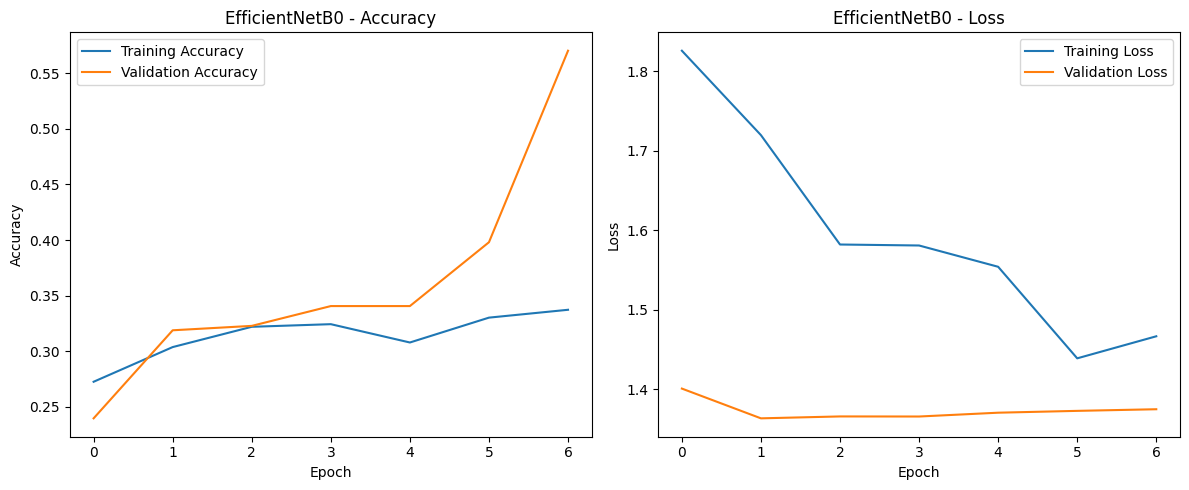

In [72]:
import matplotlib.pyplot as plt

history = efficientnetb0_history.history

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history["accuracy"], label="Training Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")
plt.title("EfficientNetB0 - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("EfficientNetB0 - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## EfficientNetB0 Training Performance

The EfficientNetB0 transfer learning model was trained using ImageNet pretrained weights with the base layers frozen and a custom classification head for four tumor categories.

- The model was trained for a maximum of **30 epochs** with **EarlyStopping** based on validation loss.
- Training stopped at **Epoch 7**, and the weights from the best-performing **Epoch 2** were restored.
- The best validation loss was **1.36327**, with a validation accuracy of **31.88%**.
- Training accuracy remained relatively low and reached approximately **33.73%** by Epoch 7.
- Validation accuracy increased during the later epochs and reached approximately **57.03% at Epoch 7**, although the validation loss did not improve after Epoch 2.
- The validation loss remained higher than the best value after Epoch 2, which triggered EarlyStopping.
- The training results indicate that the frozen EfficientNetB0 feature extractor with the current classification head did not learn the dataset as effectively as the other transfer-learning models.
- The best model checkpoint was saved as `efficientnetb0_best.keras`.

Overall, the EfficientNetB0 training results provide a useful comparison point for evaluating the performance of the different CNN architectures on the MRI dataset.

## EfficientNetB0 Independent Test Evaluation

In [73]:
# EfficientNetB0 test-set predictions

test_generator.reset()

efficientnetb0_predictions = efficientnetb0_model.predict(
    test_generator,
    verbose=1
)

y_pred_efficientnetb0 = np.argmax(
    efficientnetb0_predictions,
    axis=1
)

y_true_efficientnetb0 = test_generator.classes

print("Test images:", len(y_true_efficientnetb0))
print("Predictions:", len(y_pred_efficientnetb0))

8/8 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step
Test images: 246
Predictions: 246


## Create EfficientNetB0-specific generators

In [76]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# EfficientNetB0-specific generators
# IMPORTANT: No rescale=1./255 here because EfficientNetB0
# performs its own input rescaling internally.

efficientnet_train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2]
)

efficientnet_valid_datagen = ImageDataGenerator()
efficientnet_test_datagen = ImageDataGenerator()


efficientnet_train_generator = efficientnet_train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="File_Path",
    y_col="Class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

efficientnet_valid_generator = efficientnet_valid_datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col="File_Path",
    y_col="Class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

efficientnet_test_generator = efficientnet_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="File_Path",
    y_col="Class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("EfficientNetB0-specific generators created successfully.")

Found 1699 validated image filenames belonging to 4 classes.
Found 505 validated image filenames belonging to 4 classes.
Found 246 validated image filenames belonging to 4 classes.
EfficientNetB0-specific generators created successfully.


## Rebuild EfficientNetB0 From Fresh Weights

In [77]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

# Fresh EfficientNetB0 base
efficientnet_base_corrected = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

efficientnet_base_corrected.trainable = False

# Build corrected EfficientNetB0 classifier
efficientnetb0_corrected_model = models.Sequential([
    efficientnet_base_corrected,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

efficientnetb0_corrected_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_98          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,655 (16.72 MB)

 Trainable params: 331,524 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## Compile The Corrected Model

In [78]:
efficientnetb0_corrected_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Corrected EfficientNetB0 model compiled successfully.")

Corrected EfficientNetB0 model compiled successfully.


## EfficientNetB0 Fresh Callback

In [79]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping_efficientnet = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint_efficientnet = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Brain_Tumor_MRI_Project/efficientnetb0_corrected_best.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

print("EfficientNetB0 callbacks created successfully.")

EfficientNetB0 callbacks created successfully.


## Train The Corrected EfficientNetB0

In [80]:
EPOCHS = 30

efficientnetb0_history = efficientnetb0_corrected_model.fit(
    efficientnet_train_generator,
    validation_data=efficientnet_valid_generator,
    epochs=EPOCHS,
    callbacks=[
        early_stopping_efficientnet,
        model_checkpoint_efficientnet
    ]
)

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6204 - loss: 1.1379
Epoch 1: val_loss improved from None to 0.57517, saving model to /content/drive/MyDrive/Brain_Tumor_MRI_Project/efficientnetb0_corrected_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Brain_Tumor_MRI_Project/efficientnetb0_corrected_best.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 228s 4s/step - accuracy: 0.7075 - loss: 0.8863 - val_accuracy: 0.7921 - val_loss: 0.5752
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8350 - loss: 0.4965
Epoch 2: val_loss improved from 0.57517 to 0.55720, saving model to /content/drive/MyDrive/Brain_Tumor_MRI_Project/efficientnetb0_corrected_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Brain_Tumor_MRI_Project/efficientnetb0_corrected_best.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 259s 4s/step - accuracy: 0.8346 - loss: 0.5005 - val_accuracy: 0.7861 - val_loss: 0.5572
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8509

## EfficientNetB0 Training Curves

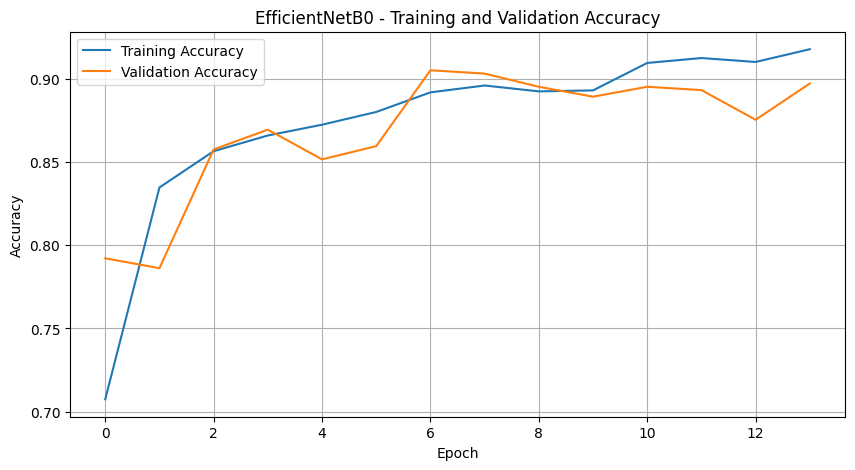

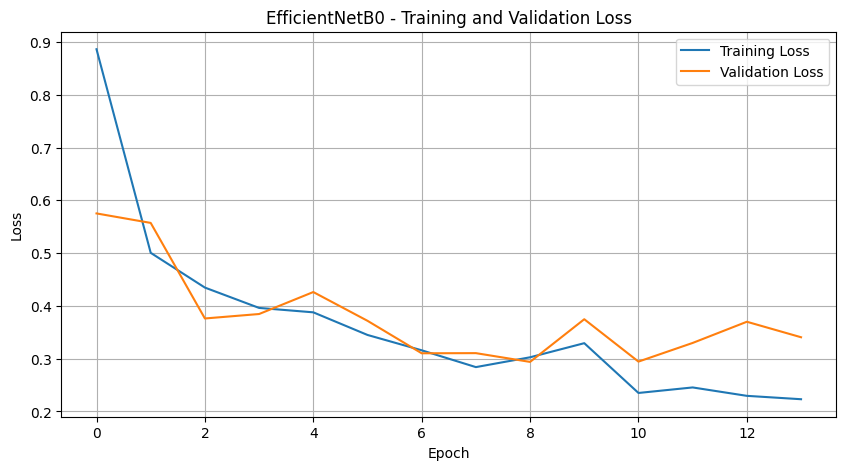

In [81]:
import matplotlib.pyplot as plt

# Training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(
    efficientnetb0_history.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    efficientnetb0_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("EfficientNetB0 - Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# Training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(
    efficientnetb0_history.history["loss"],
    label="Training Loss"
)
plt.plot(
    efficientnetb0_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("EfficientNetB0 - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


#### EfficientNetB0 Training Summary

The EfficientNetB0 transfer learning model was trained using ImageNet pretrained weights with the base model frozen and a custom classification head for four tumor categories.

- Maximum epochs: 30
- Actual epochs completed: 14
- Best epoch based on validation loss: 9
- Best validation loss: 0.29380
- Validation accuracy at the best-loss epoch: 89.50%
- Highest validation accuracy: 90.50% at Epoch 7
- EarlyStopping restored the weights from Epoch 9.

The training accuracy increased steadily throughout training, while validation accuracy remained relatively close to the training accuracy. Some fluctuations were observed in validation performance, but there was no severe separation between the training and validation curves.

## EfficientNetB0 Test Evaluation

In [82]:
efficientnet_test_generator.reset()

efficientnet_test_predictions = efficientnetb0_corrected_model.predict(
    efficientnet_test_generator,
    verbose=1
)

efficientnet_y_pred = np.argmax(efficientnet_test_predictions, axis=1)
efficientnet_y_true = efficientnet_test_generator.classes

print("Test images:", len(efficientnet_y_true))
print("Predictions:", len(efficientnet_y_pred))

8/8 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step
Test images: 246
Predictions: 246


## Class-wise Classification Report



In [83]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

efficientnet_accuracy = accuracy_score(
    efficientnet_y_true,
    efficientnet_y_pred
)

efficientnet_precision = precision_score(
    efficientnet_y_true,
    efficientnet_y_pred,
    average="weighted",
    zero_division=0
)

efficientnet_recall = recall_score(
    efficientnet_y_true,
    efficientnet_y_pred,
    average="weighted",
    zero_division=0
)

efficientnet_f1 = f1_score(
    efficientnet_y_true,
    efficientnet_y_pred,
    average="weighted",
    zero_division=0
)

print(f"Test Accuracy : {efficientnet_accuracy:.4f} ({efficientnet_accuracy*100:.2f}%)")
print(f"Precision     : {efficientnet_precision:.4f} ({efficientnet_precision*100:.2f}%)")
print(f"Recall        : {efficientnet_recall:.4f} ({efficientnet_recall*100:.2f}%)")
print(f"F1-Score      : {efficientnet_f1:.4f} ({efficientnet_f1*100:.2f}%)")

print("\nClassification Report:\n")

print(
    classification_report(
        efficientnet_y_true,
        efficientnet_y_pred,
        target_names=classes,
        digits=4,
        zero_division=0
    )
)

Test Accuracy : 0.8821 (88.21%)
Precision     : 0.8823 (88.23%)
Recall        : 0.8821 (88.21%)
F1-Score      : 0.8807 (88.07%)

Classification Report:

              precision    recall  f1-score   support

      glioma     0.8916    0.9250    0.9080        80
  meningioma     0.8065    0.7937    0.8000        63
    no_tumor     0.9286    0.7959    0.8571        49
   pituitary     0.9153    1.0000    0.9558        54

    accuracy                         0.8821       246
   macro avg     0.8855    0.8786    0.8802       246
weighted avg     0.8823    0.8821    0.8807       246



## EfficientNetB0 confusion matrix

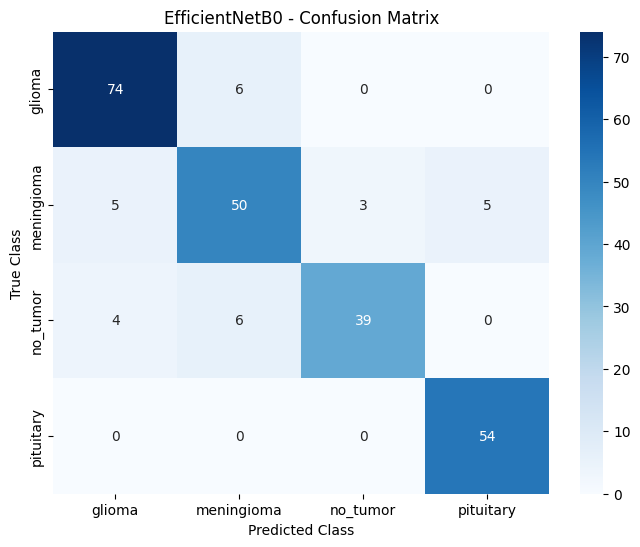

In [84]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

efficientnet_cm = confusion_matrix(
    efficientnet_y_true,
    efficientnet_y_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    efficientnet_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title("EfficientNetB0 - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

#### EfficientNetB0 Evaluation Summary

The corrected EfficientNetB0 model was evaluated on the independent test set containing 246 MRI images.

The model achieved:

- Test Accuracy: 88.21%
- Weighted Precision: 88.23%
- Weighted Recall: 88.21%
- Weighted F1-Score: 88.07%

The confusion matrix shows that 74 of 80 glioma images, 50 of 63 meningioma images, 39 of 49 no-tumor images, and all 54 pituitary images were correctly classified.

The model achieved perfect classification for the pituitary class in this test set. Meningioma showed comparatively more misclassifications, mainly with glioma and pituitary classes.

Overall, EfficientNetB0 provided strong classification performance and will be considered for comparison with the Custom CNN, ResNet50, MobileNetV2, and InceptionV3 models.

## EfficientNetB0 .h5

In [85]:
efficientnet_final_h5_path = (
    "/content/drive/MyDrive/Brain_Tumor_MRI_Project/"
    "efficientnetb0_best.h5"
)

efficientnetb0_corrected_model.save(efficientnet_final_h5_path)

print("EfficientNetB0 final model saved successfully:")
print(efficientnet_final_h5_path)


EfficientNetB0 final model saved successfully:
/content/drive/MyDrive/Brain_Tumor_MRI_Project/efficientnetb0_best.h5


## Model Comparison

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

model_comparison = pd.DataFrame({
    "Model": [
        "Custom CNN",
        "ResNet50",
        "MobileNetV2",
        "InceptionV3",
        "EfficientNetB0"
    ],
    "Accuracy": [
        81.30,
        78.05,
        84.15,
        86.18,
        88.21
    ],
    "Precision": [
        83.49,
        77.81,
        84.72,
        86.39,
        88.23
    ],
    "Recall": [
        81.30,
        78.05,
        84.15,
        86.18,
        88.21
    ],
    "F1-Score": [
        81.46,
        77.44,
        83.61,
        86.14,
        88.07
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Custom CNN,81.30,83.49,81.30,81.46
1,ResNet50,78.05,77.81,78.05,77.44
2,MobileNetV2,84.15,84.72,84.15,83.61
3,InceptionV3,86.18,86.39,86.18,86.14
4,EfficientNetB0,88.21,88.23,88.21,88.07


## Create The Model Comparison Chart

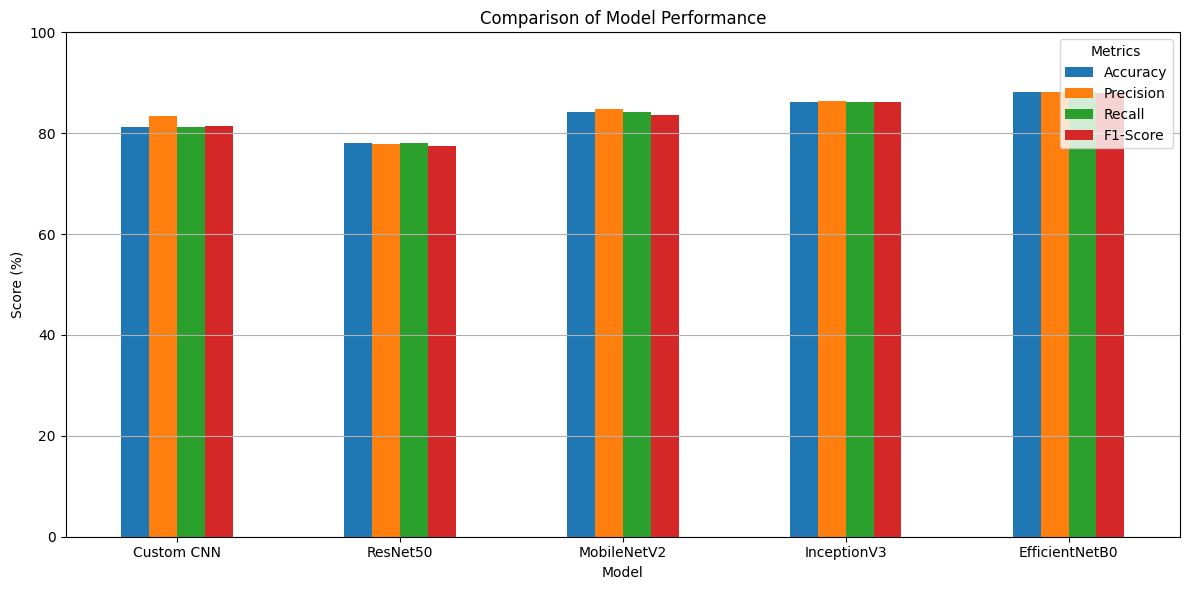

In [88]:
import matplotlib.pyplot as plt

# Model comparison chart
model_comparison.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Model Performance")
plt.xlabel("Model")
plt.ylabel("Score (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

## ***9.*** ***Future Work (Optional)***

## Load the saved model file and try to predict unseen data for a sanity check.


In [89]:
from tensorflow.keras.models import load_model

loaded_efficientnet = load_model(
    "/content/drive/MyDrive/Brain_Tumor_MRI_Project/efficientnetb0_best.h5"
)

print("EfficientNetB0 .h5 model loaded successfully.")

EfficientNetB0 .h5 model loaded successfully.


## sanity-check prediction from the reloaded .h5

In [90]:
import numpy as np

# Reset test generator
efficientnet_test_generator.reset()

# Take one batch from the test generator
sample_images, sample_labels = next(efficientnet_test_generator)

# Predict using the reloaded .h5 model
sample_predictions = loaded_efficientnet.predict(
    sample_images,
    verbose=0
)

sample_predicted_classes = np.argmax(sample_predictions, axis=1)
sample_actual_classes = np.argmax(sample_labels, axis=1)

print("Sample batch image shape:", sample_images.shape)
print("Prediction shape:", sample_predictions.shape)

print("\nFirst 5 actual classes:")
print([classes[i] for i in sample_actual_classes[:5]])

print("\nFirst 5 predicted classes:")
print([classes[i] for i in sample_predicted_classes[:5]])

print("\nFirst 5 prediction confidence scores:")
print(np.max(sample_predictions[:5], axis=1))

Sample batch image shape: (32, 224, 224, 3)
Prediction shape: (32, 4)

First 5 actual classes:
['glioma', 'glioma', 'glioma', 'glioma', 'glioma']

First 5 predicted classes:
['glioma', 'glioma', 'glioma', 'glioma', 'glioma']

First 5 prediction confidence scores:
[0.99996036 0.999991   0.996939   0.99995214 0.9999319 ]


#### Saved Model Sanity Check

The saved EfficientNetB0 model was reloaded successfully from the `.h5` file and tested on a sample batch of previously unseen test images.

The reloaded model accepted images of size 224 × 224 × 3 and produced four-class prediction probabilities. The first five test images were correctly predicted as glioma, confirming that the saved model can be successfully restored and used for inference.

## 10. Streamlit Application

The Streamlit application provides an interactive interface for uploading a brain MRI image and obtaining an AI-assisted prediction of the tumor category along with the prediction confidence.

The selected EfficientNetB0 model is used for inference because it achieved the best performance among the evaluated models.

The application was deployed using Streamlit Community Cloud and successfully tested with MRI images representing all four classes:

- Glioma
- Meningioma
- No Tumor
- Pituitary

The deployed application accepts JPG, JPEG, and PNG MRI images, displays the uploaded image, predicts the tumor category, and shows the prediction confidence and class probabilities.

The application is intended for AI-assisted research and educational purposes and is not a medical diagnosis.

# **Conclusion**



This project successfully developed a deep learning-based system for classifying brain MRI images into four categories: **glioma, meningioma, no tumor, and pituitary**. The complete workflow included data exploration, preprocessing, augmentation, custom CNN development, transfer learning, model evaluation, comparison, and application deployment.

Among the evaluated models, **EfficientNetB0 achieved the best overall performance**, with **88.21% accuracy, 88.23% precision, 88.21% recall, and 88.07% F1-score** on the test dataset. Therefore, EfficientNetB0 was selected as the final model for the Streamlit application.

The deployed Streamlit application successfully accepted MRI images and provided the predicted tumor category, prediction confidence, and class probabilities. Testing with images from all four categories demonstrated that the application and inference pipeline were functioning successfully.

Overall, the project demonstrates how deep learning and transfer learning can be applied to brain MRI image classification and converted into an interactive application. The system is intended for **AI-assisted research and educational purposes and should not be considered a medical diagnosis**.